# HK distances and transport plans — smoke tests

Synthetic 30×30 Gaussian-blob maps exercise `analysis.hk_distance.maps_hk_with_plan`.
Each test shows **Map A**, **Map B**, and three **coupling plans** (departure / arrival / top flows) for `HK_METHOD`, **SUOT**, and **ROT**, with **HK²** and **HK** reported for each.

Configure the solver in the next cell: `HK_METHOD` (`"custom"` or `"solve_hk"`), `MAX_ITER`, Sinkhorn hyperparameters, and SUOT/ROT penalty strengths.
All tests use `hk_scale = 10` unless noted.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        for _p in (str(_path), str(_path / "src")):
            if _p not in sys.path:
                sys.path.insert(0, _p)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.hk_distance import maps_hk_with_plan
from analysis.weighted_w2_distance import weighted_w2_distance

GRID_SHAPE = (30, 30)
HK_SCALE = 20.0
TOP_FLOWS = 30

# Solver backend: "custom" (independent Sinkhorn) or "solve_hk" (external SolveHK)
HK_METHOD = "custom"
MAX_ITER = 100
SINKHORN_ERROR = 1e-4
EPS_TARGET = 1e-3
EPS_INIT = 1.0

# Hard-source / soft-target variants (shown alongside HK_METHOD in each test plot)
SUOT_RHO = 10# 1.0
ROT_GAMMA = 10#  1.0
MASS_EPS_COMPARISON = 1e-4

In [2]:
def gaussian_blob(shape, cy, cx, sigma=2.0, amplitude=1.0):
    ys, xs = np.indices(shape)
    return amplitude * np.exp(-((ys - cy) ** 2 + (xs - cx) ** 2) / (2 * sigma ** 2))


def build_map(shape, blobs):
    total = np.zeros(shape, dtype=np.float64)
    for b in blobs:
        total += gaussian_blob(shape, **b)
    return total


def blob_desc(blobs):
    parts = []
    for i, b in enumerate(blobs, 1):
        parts.append(
            f"#{i} center=({b['cy']},{b['cx']}), σ={b['sigma']}, amp={b['amplitude']}"
        )
    return "; ".join(parts)


def plan_on_grids(plan, pos_a, pos_b, shape):
    depart = np.zeros(shape)
    arrive = np.zeros(shape)
    for i, (y, x) in enumerate(pos_a.astype(int)):
        depart[y, x] += plan[i, :].sum()
    for j, (y, x) in enumerate(pos_b.astype(int)):
        arrive[y, x] += plan[:, j].sum()
    return depart, arrive


def top_plan_pairs(plan, pos_a, pos_b, k=25):
    flat_idx = np.argsort(plan.ravel())[::-1][:k]
    pairs = []
    for idx in flat_idx:
        mass = plan.ravel()[idx]
        if mass <= 0:
            break
        i, j = divmod(int(idx), plan.shape[1])
        pairs.append((pos_a[i], pos_b[j], mass))
    return pairs


def run_hk_test(
    test_id,
    title,
    blobs_a,
    blobs_b,
    *,
    hk_scale=HK_SCALE,
    method=HK_METHOD,
    max_iter=MAX_ITER,
    suot_rho=SUOT_RHO,
    rot_gamma=ROT_GAMMA,
    mass_eps=MASS_EPS_COMPARISON,
):
    map_a = build_map(GRID_SHAPE, blobs_a)
    map_b = build_map(GRID_SHAPE, blobs_b)
    w2_dist = weighted_w2_distance(
        map_a,
        map_b,
        n_gaussians_a=len(blobs_a),
        n_gaussians_b=len(blobs_b),
    )

    method_rows = [
        (method, f"{method}", {}),
        ("suot", f"SUOT ρ={suot_rho}", {"rho": suot_rho}),
        ("rot", f"ROT γ={rot_gamma}", {"gamma": rot_gamma}),
    ]

    results_by_method = {}
    for meth_key, label, kw in method_rows:
        hk2, plan, pos_a, pos_b, mu_a, mu_b = maps_hk_with_plan(
            map_a,
            map_b,
            method=meth_key,
            hk_scale=hk_scale,
            sinkhorn_error=SINKHORN_ERROR,
            eps_target=EPS_TARGET,
            eps_init=EPS_INIT,
            max_iter=max_iter,
            mass_eps=mass_eps,
            **kw,
        )
        depart, arrive = plan_on_grids(plan, pos_a, pos_b, GRID_SHAPE)
        flows = top_plan_pairs(plan, pos_a, pos_b, k=TOP_FLOWS)
        results_by_method[label] = {
            "hk2": float(hk2),
            "hk": float(np.sqrt(hk2)),
            "depart": depart,
            "arrive": arrive,
            "flows": flows,
            "mu_a": mu_a,
            "mu_b": mu_b,
            "plan": plan,
        }

    primary_label = f"{method}"
    primary = results_by_method[primary_label]
    hk2, hk = primary["hk2"], primary["hk"]

    n_plan_rows = len(method_rows)
    fig, axes = plt.subplots(
        1 + n_plan_rows,
        3,
        figsize=(14, 4 + 3 * n_plan_rows),
        constrained_layout=True,
    )

    rate_vmax = max(float(map_a.max()), float(map_b.max()), 1e-9)
    map_axes = []
    for ax, data, label in [
        (axes[0, 0], map_a, "Map A"),
        (axes[0, 1], map_b, "Map B"),
    ]:
        im = ax.imshow(data, cmap="YlGnBu", vmin=0, vmax=rate_vmax)
        ax.set_title(f"{label} (peak={data.max():.3g})")
        ax.set_xticks([])
        ax.set_yticks([])
        map_axes.append(ax)
    fig.colorbar(
        im,
        ax=map_axes,
        fraction=0.046,
        pad=0.04,
        label="rate",
    )

    info = axes[0, 2]
    info.axis("off")
    method_lines = "\n".join(
        f"{lbl}: HK²={res['hk2']:.2f}  HK={res['hk']:.2f}"
        for lbl, res in results_by_method.items()
    )
    info.text(
        0.02,
        0.98,
        f"{test_id}: {title}\n\n"
        f"A: {blob_desc(blobs_a)}\n\n"
        f"B: {blob_desc(blobs_b)}\n\n"
        f"mass(A) = {map_a.sum():.2f}\n"
        f"mass(B) = {map_b.sum():.2f}\n\n"
        f"{method_lines}\n\n"
        f"weighted_w2 = {w2_dist:.2f}\n\n"
        f"max_iter = {max_iter}\n"
        f"hk_scale = {hk_scale}\n"
        f"mass_eps = {mass_eps}",
        va="top",
        fontsize=9,
        family="monospace",
    )

    for row_idx, (meth_key, label, _) in enumerate(method_rows):
        res = results_by_method[label]
        depart, arrive, flows = res["depart"], res["arrive"], res["flows"]
        mu_a, mu_b = res["mu_a"], res["mu_b"]
        plan = res["plan"]
        ax_row = row_idx + 1

        src_total = plan.sum(axis=1).sum()
        tgt_total = plan.sum(axis=0).sum()
        sparsity = float((plan == 0).sum()) / plan.size * 100

        dmax = max(depart.max(), arrive.max(), 1e-9)
        for ax, data, panel in [
            (axes[ax_row, 0], depart, "Plan departure (on A grid)"),
            (axes[ax_row, 1], arrive, "Plan arrival (on B grid)"),
        ]:
            im_plan = ax.imshow(data, cmap="Oranges", vmin=0, vmax=dmax)
            ax.set_title(
                f"{label}\n{panel}\n"
                f"val={res['hk2']:.3f}  sparsity={sparsity:.0f}%"
            )
            ax.set_xticks([])
            ax.set_yticks([])
            fig.colorbar(
                im_plan, ax=ax, fraction=0.046, pad=0.04, label="plan mass"
            )

        ax_flow = axes[ax_row, 2]
        ax_flow.imshow(
            0.5 * (map_a + map_b),
            cmap="Greys",
            vmin=0,
            vmax=rate_vmax,
            alpha=0.35,
        )
        ax_flow.set_title(
            f"{label} — Top-{TOP_FLOWS} flows\n"
            f"π₁·sum={src_total:.3f} (≈M(A)={mu_a.sum():.3f})\n"
            f"π₂·sum={tgt_total:.3f}  M(B)={mu_b.sum():.3f}"
        )
        ax_flow.set_xticks([])
        ax_flow.set_yticks([])
        if flows:
            wmax = flows[0][2]
            for (ya, xa), (yb, xb), mass in flows:
                alpha = 0.25 + 0.75 * (mass / wmax)
                ax_flow.annotate(
                    "",
                    xy=(xb, yb),
                    xytext=(xa, ya),
                    arrowprops=dict(
                        arrowstyle="->", color="crimson", lw=0.8, alpha=alpha
                    ),
                )

    fig.suptitle(f"{test_id} — {title}", fontsize=12)
    plt.show()

    return {
        "test_id": test_id,
        "title": title,
        "config_a": blob_desc(blobs_a),
        "config_b": blob_desc(blobs_b),
        "mass_a": float(map_a.sum()),
        "mass_b": float(map_b.sum()),
        "hk2": hk2,
        "hk": hk,
        "hk_scale": hk_scale,
        "method": method,
        "max_iter": max_iter,
        "suot_hk2": results_by_method[f"SUOT ρ={suot_rho}"]["hk2"],
        "suot_hk": results_by_method[f"SUOT ρ={suot_rho}"]["hk"],
        "rot_hk2": results_by_method[f"ROT γ={rot_gamma}"]["hk2"],
        "rot_hk": results_by_method[f"ROT γ={rot_gamma}"]["hk"],
        "weighted_w2": float(w2_dist),
        "map_a": map_a,
        "map_b": map_b,
    }

## Standard blob sizes

- **Large**: σ=2.5, amplitude=1.0
- **Small**: σ=1.8, amplitude=0.6
- **Extra-large** (1.5× large σ): σ=3.75, amplitude=1.0

In [3]:
LARGE = dict(sigma=2.5, amplitude=1.0)
SMALL = dict(sigma=1.8, amplitude=0.6)
XLARGE = dict(sigma=3.75, amplitude=1.0)


def B(cy, cx, spec):
    return {"cy": cy, "cx": cx, **spec}


results = []

## Smoke tests

### T01: Far apart (large top-right vs small bottom-left)

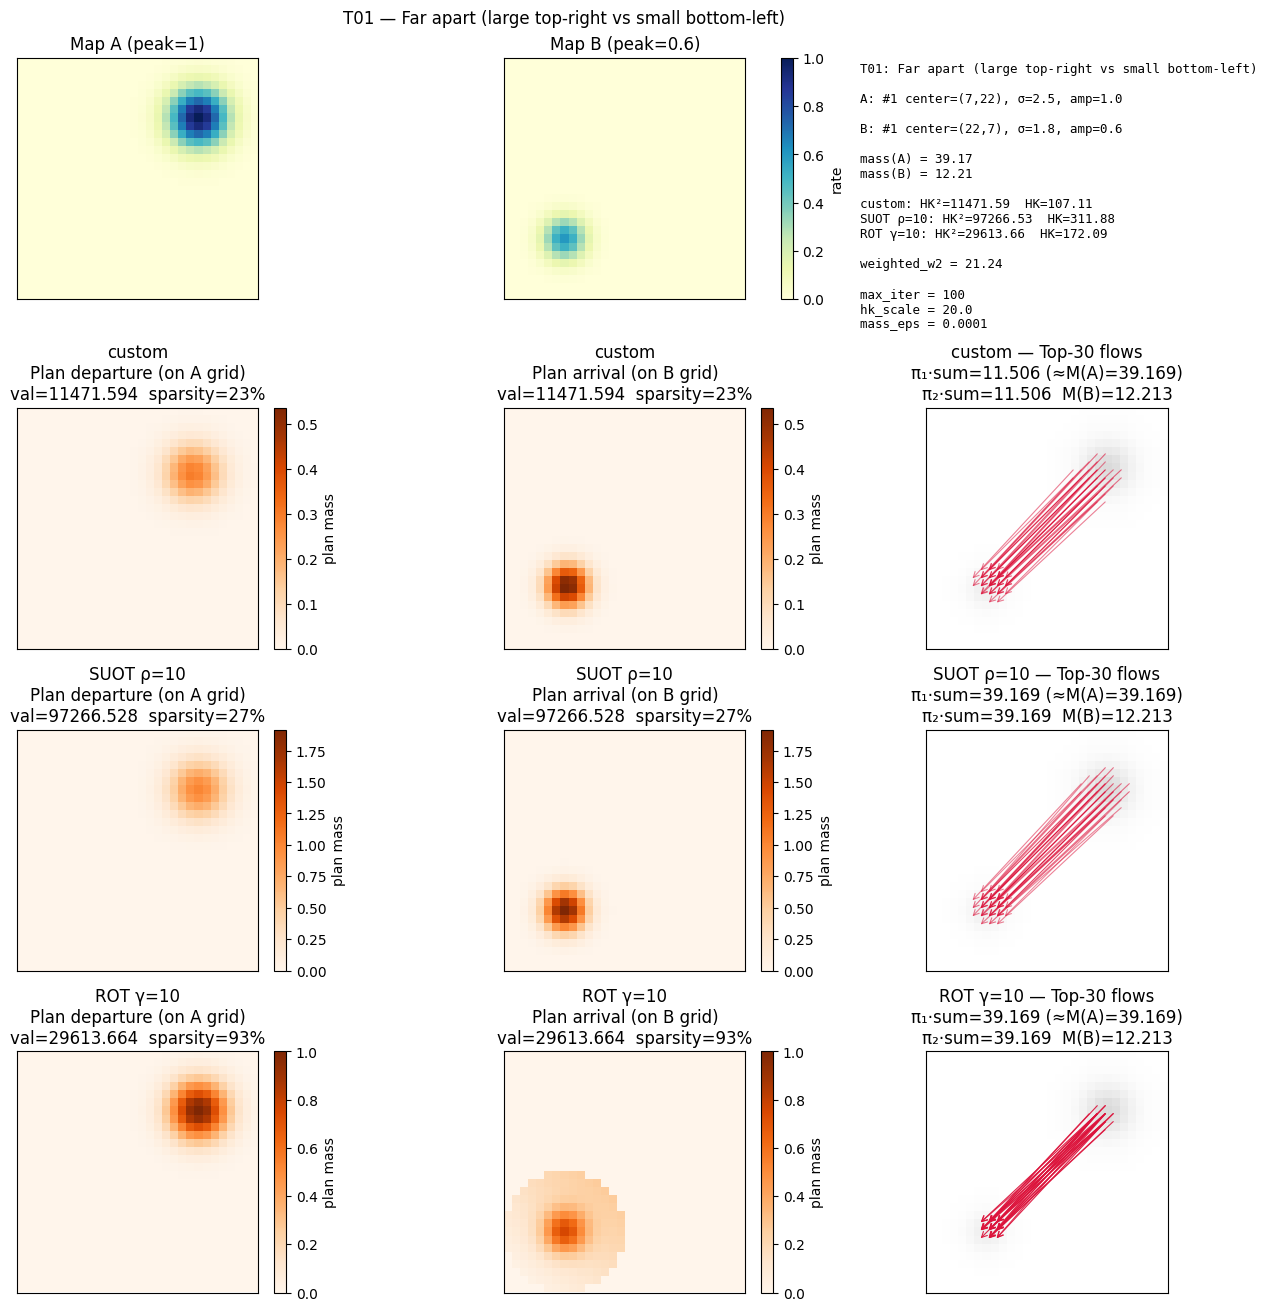

In [4]:
results.append(run_hk_test(
    "T01",
    "Far apart (large top-right vs small bottom-left)",
    [B(7, 22, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(22, 7, {'sigma': 1.8, 'amplitude': 0.6})],
))

### T02: Very close (~2.8 px)

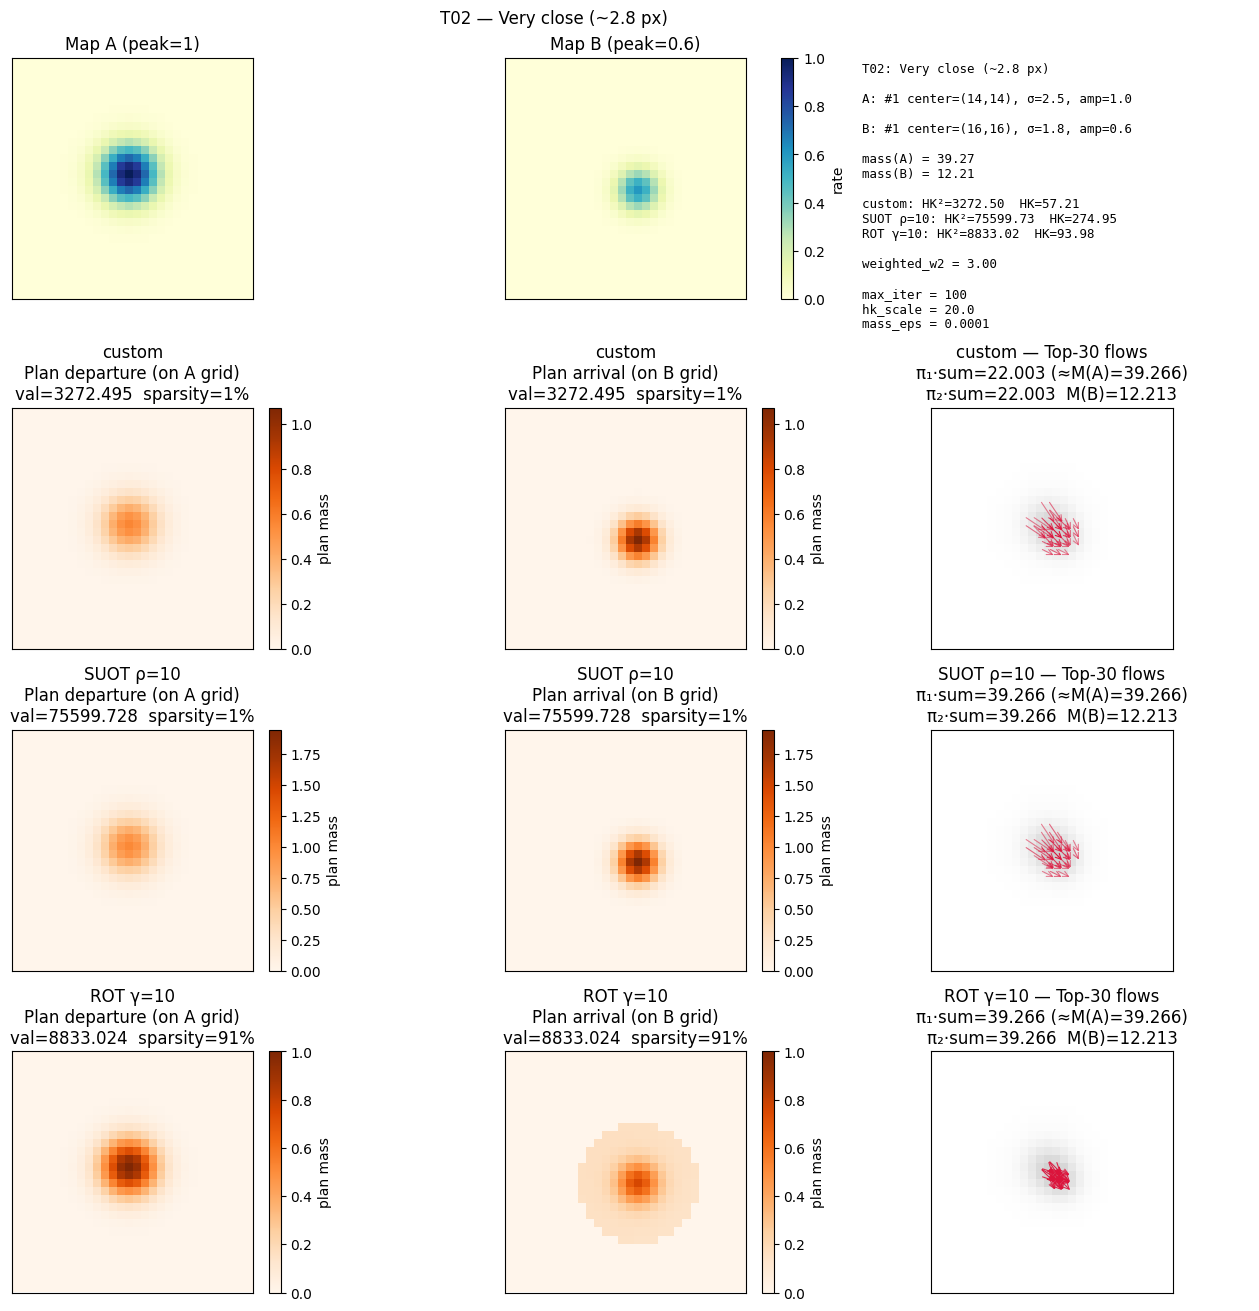

In [5]:
results.append(run_hk_test(
    "T02",
    "Very close (~2.8 px)",
    [B(14, 14, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(16, 16, {'sigma': 1.8, 'amplitude': 0.6})],
))

### T03: Double top vs single bottom center

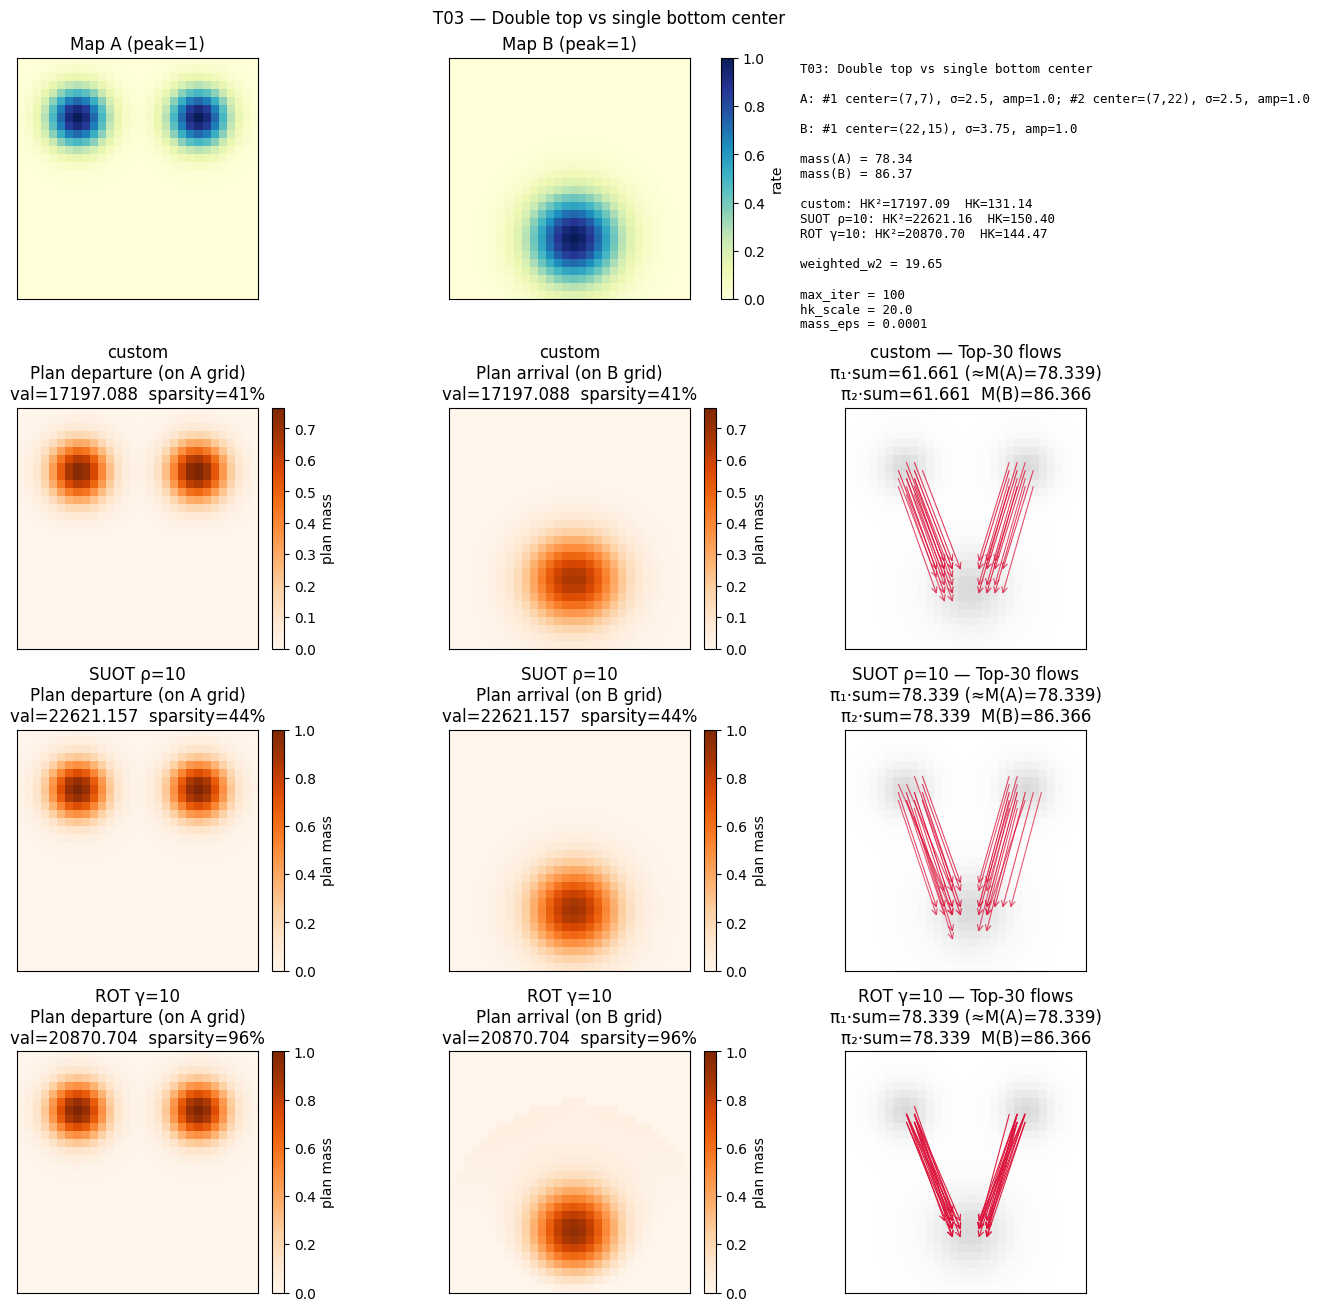

In [6]:
results.append(run_hk_test(
    "T03",
    "Double top vs single bottom center",
    [B(7, 7, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 22, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(22, 15, {'sigma': 3.75, 'amplitude': 1.0})],
))

### T04: Double top vs single bottom left

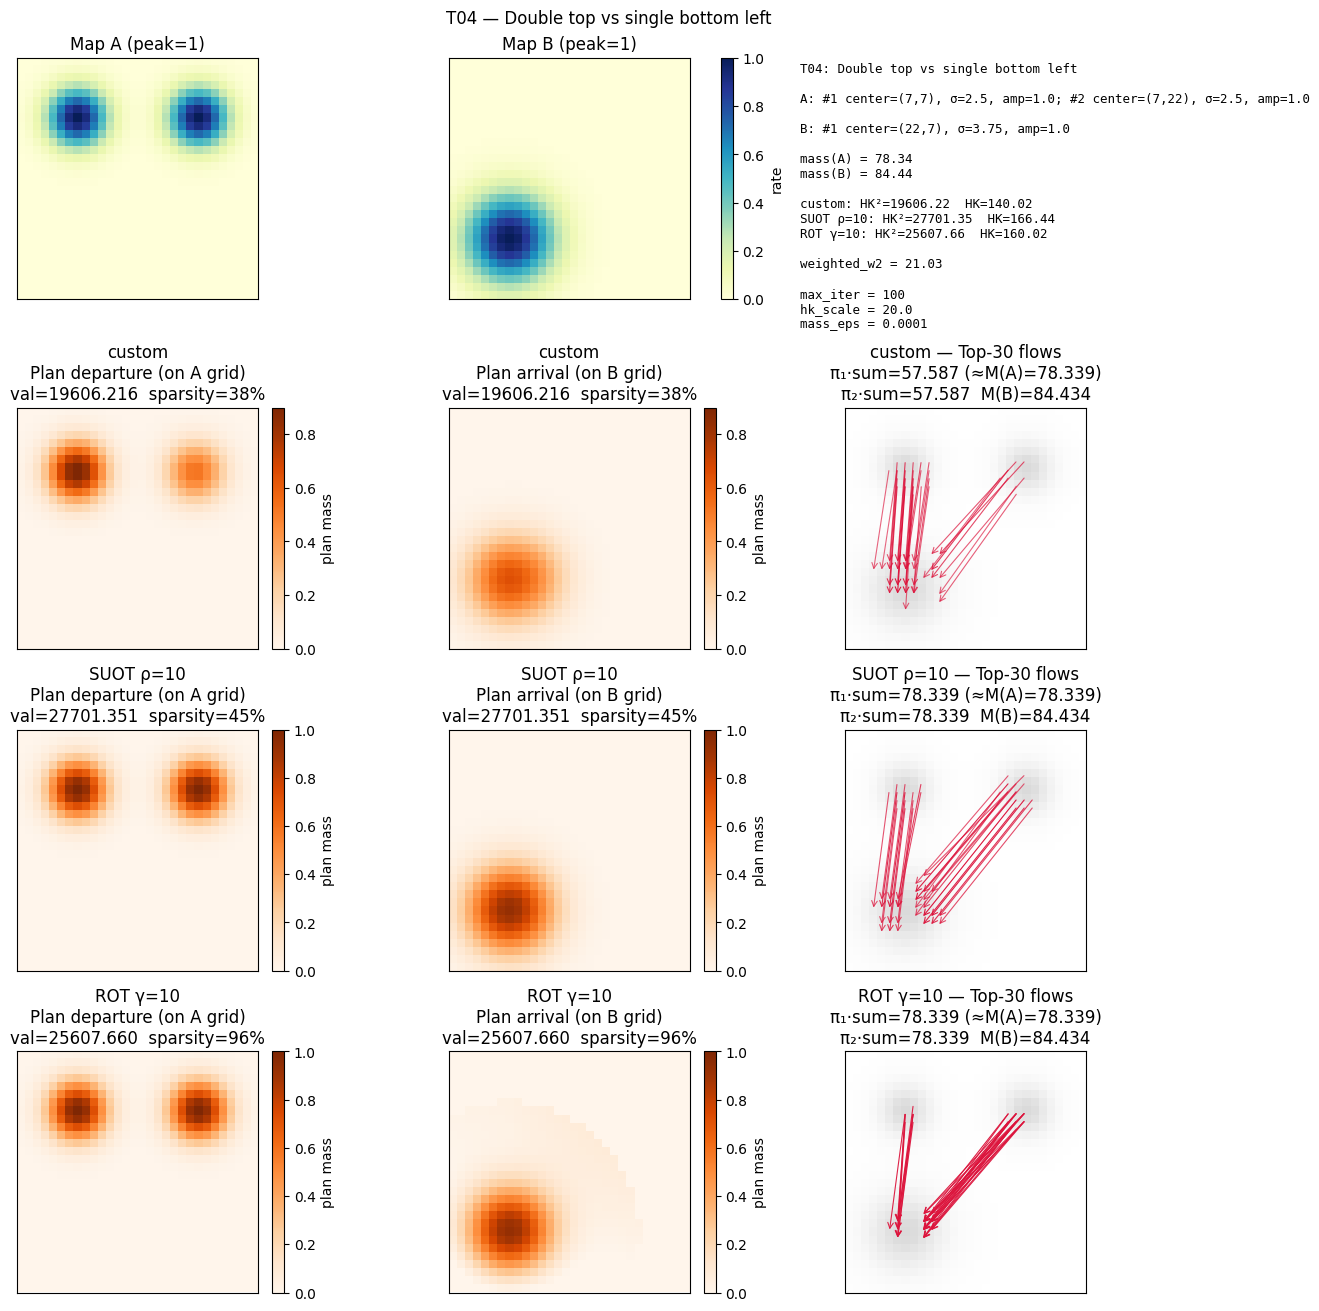

In [7]:
results.append(run_hk_test(
    "T04",
    "Double top vs single bottom left",
    [B(7, 7, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 22, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(22, 7, {'sigma': 3.75, 'amplitude': 1.0})],
))

### T05: Double top vs single top center

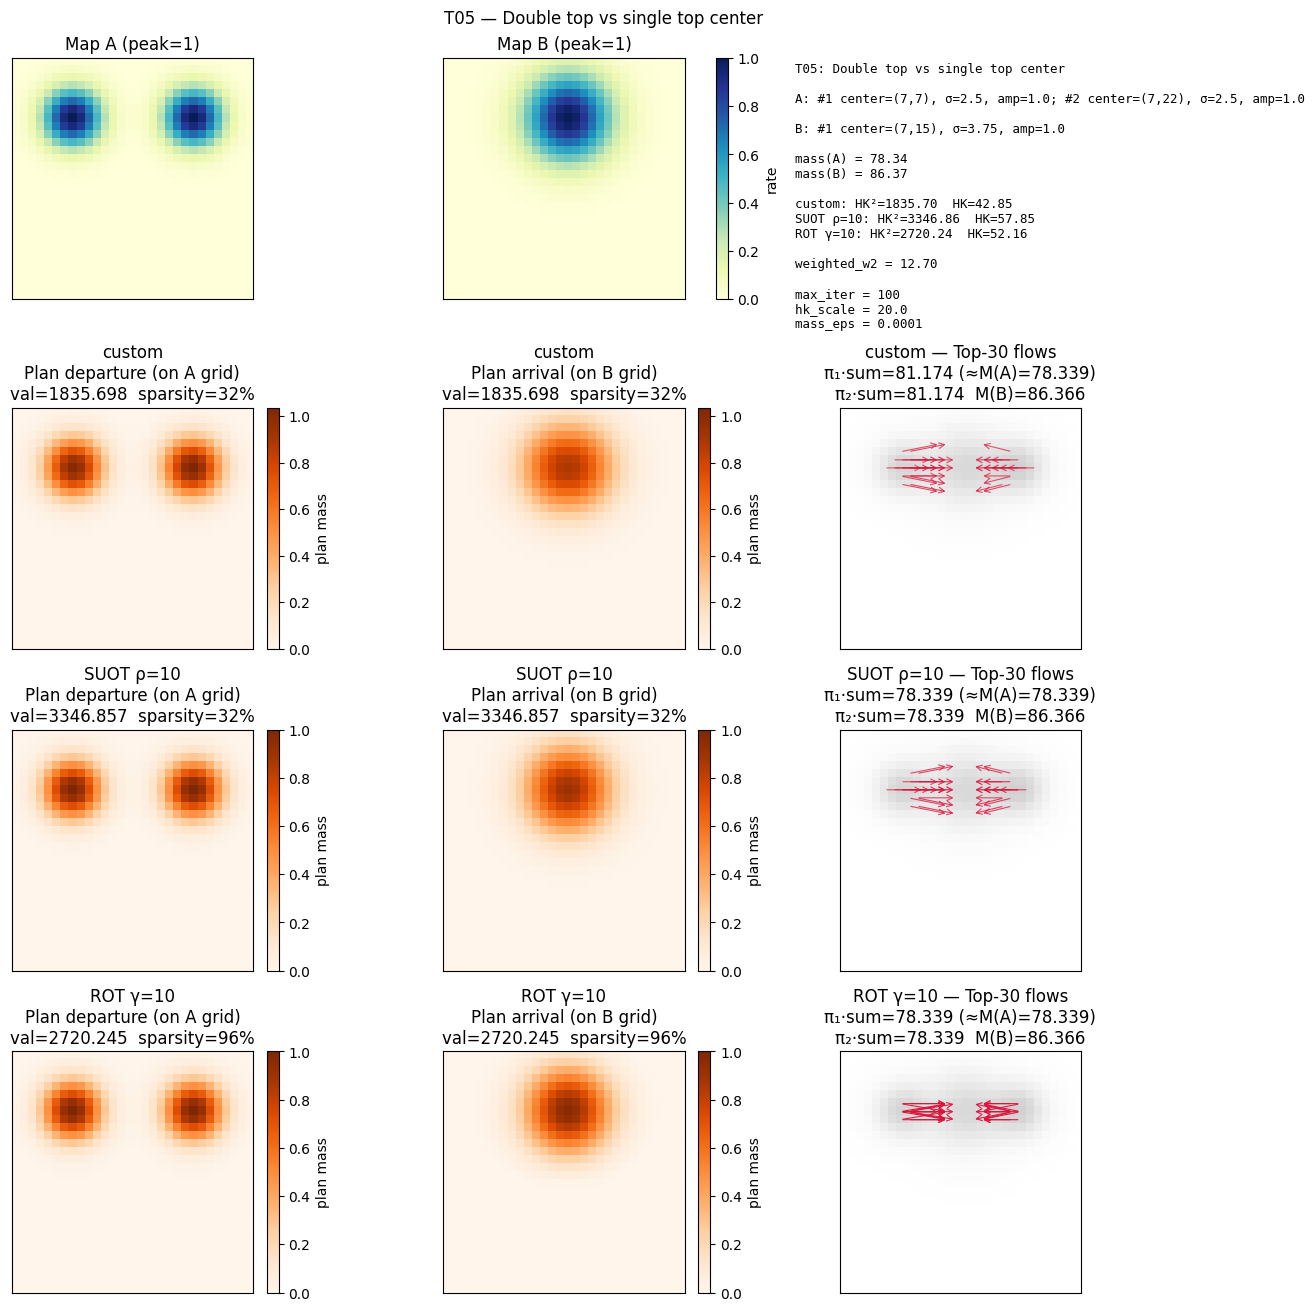

In [8]:
results.append(run_hk_test(
    "T05",
    "Double top vs single top center",
    [B(7, 7, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 22, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(7, 15, {'sigma': 3.75, 'amplitude': 1.0})],
))

### T06: Identical large blob (self, bias baseline)

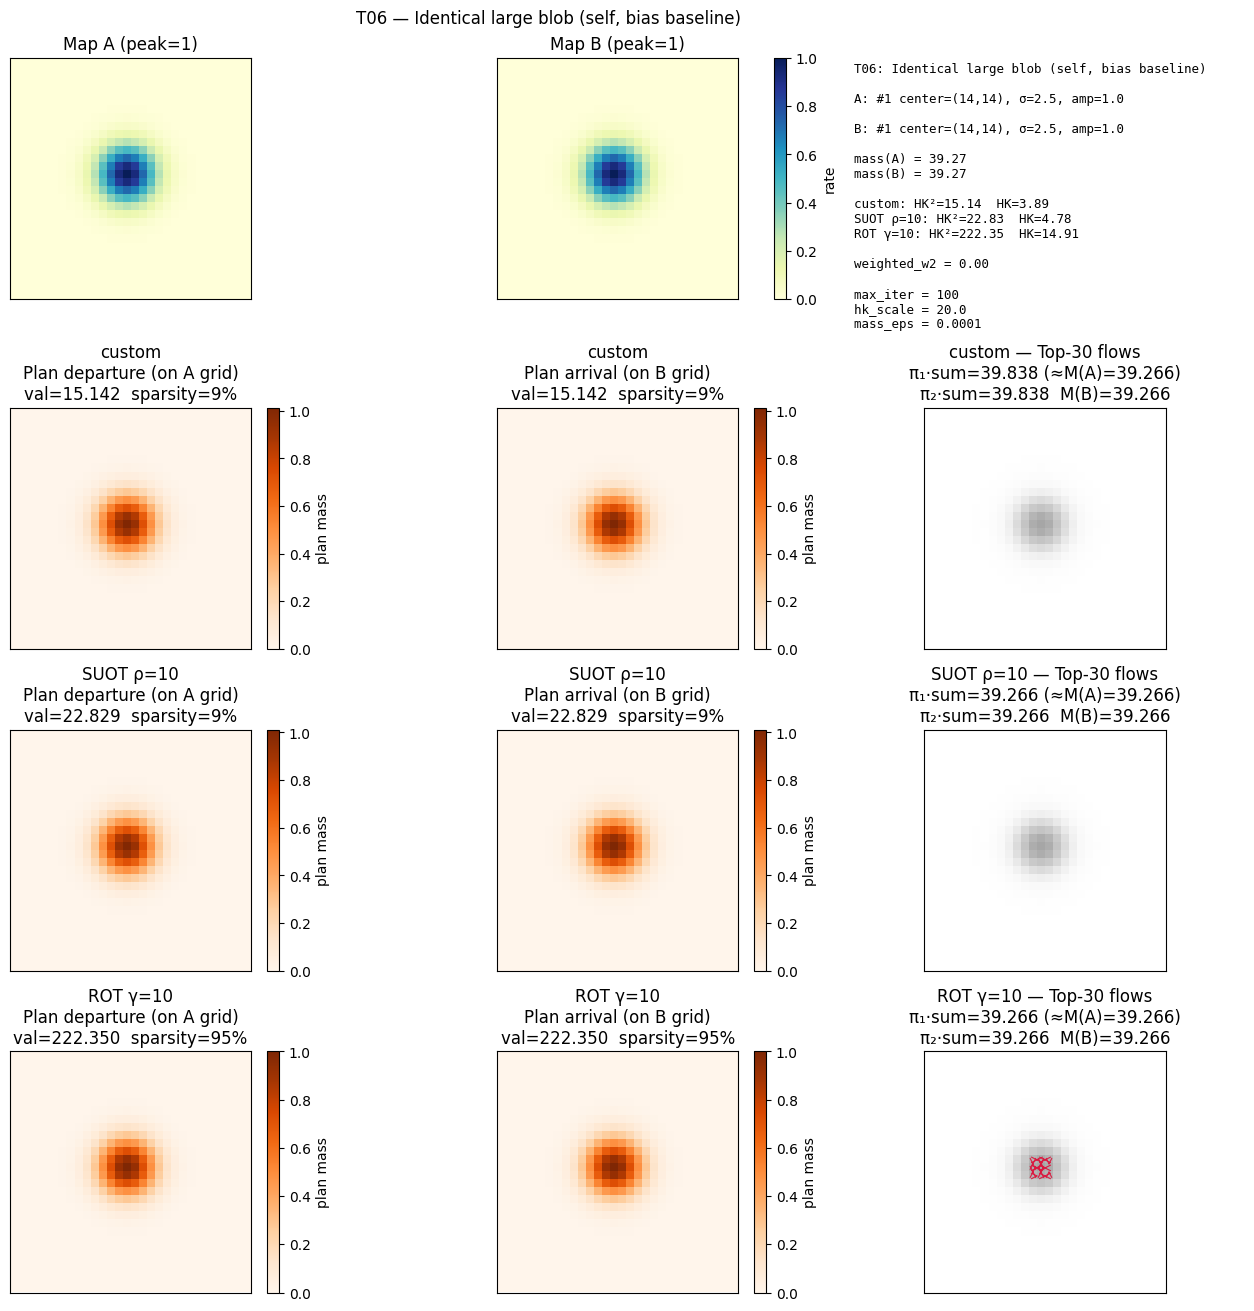

In [9]:
results.append(run_hk_test(
    "T06",
    "Identical large blob (self, bias baseline)",
    [B(14, 14, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(14, 14, {'sigma': 2.5, 'amplitude': 1.0})],
))

### T07: Same position, different amplitude

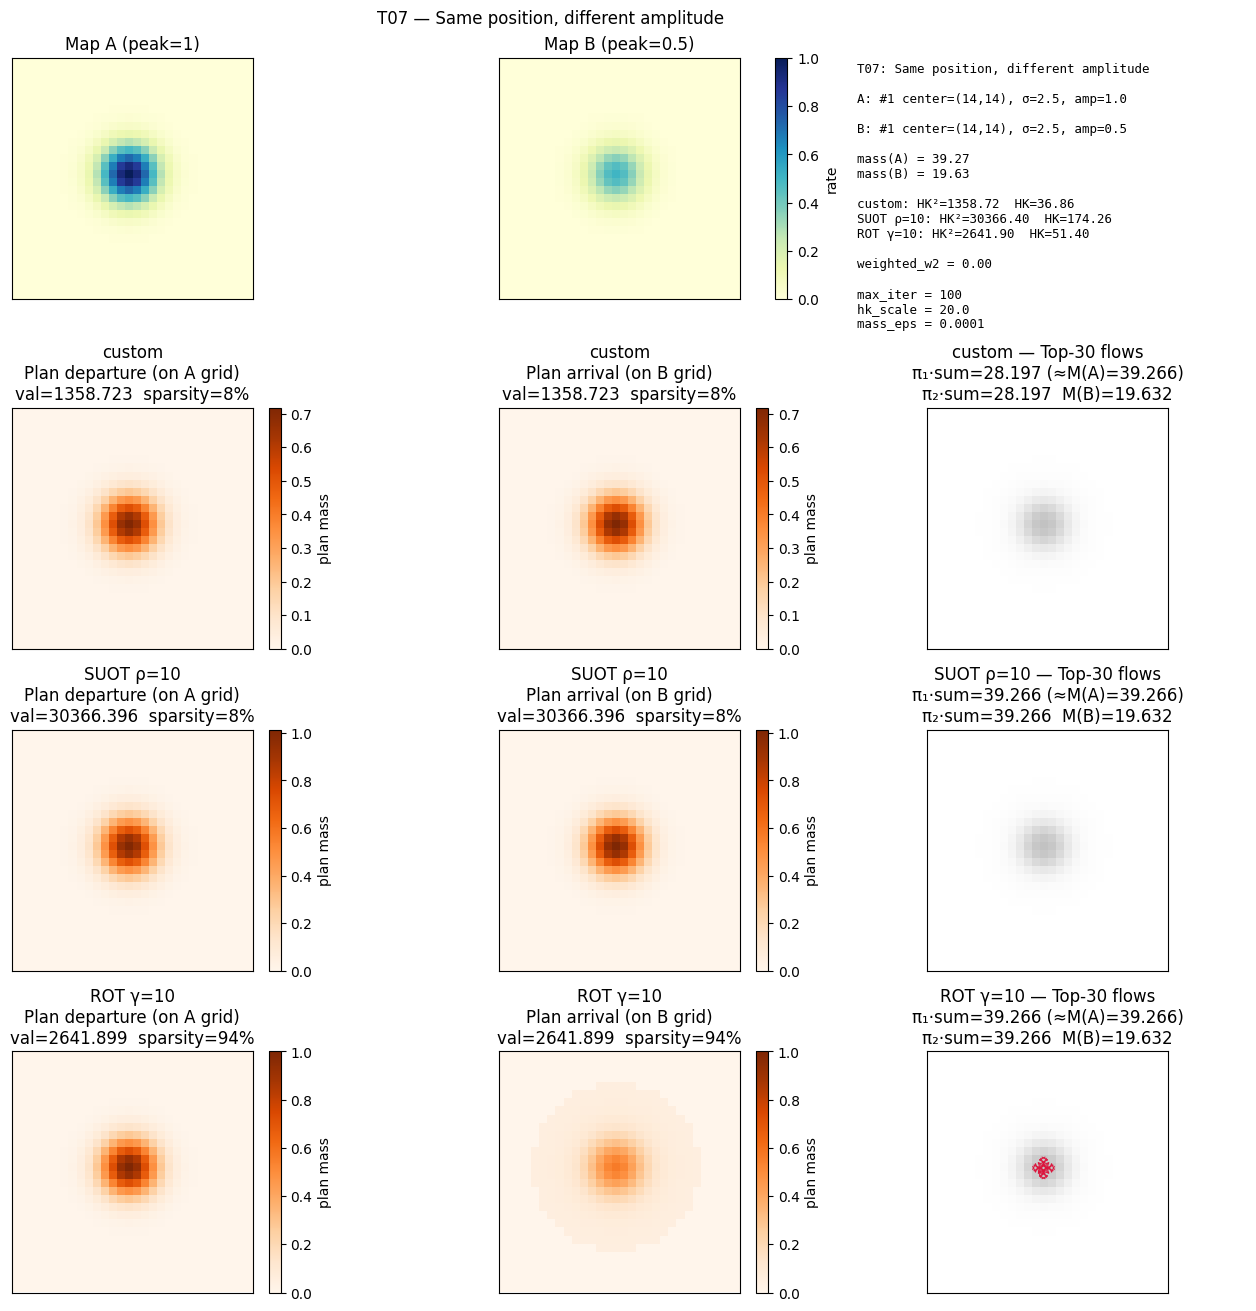

In [10]:
results.append(run_hk_test(
    "T07",
    "Same position, different amplitude",
    [B(14, 14, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(14, 14, {'sigma': 2.5, 'amplitude': 0.5})],
))

### T08: Same center, different width

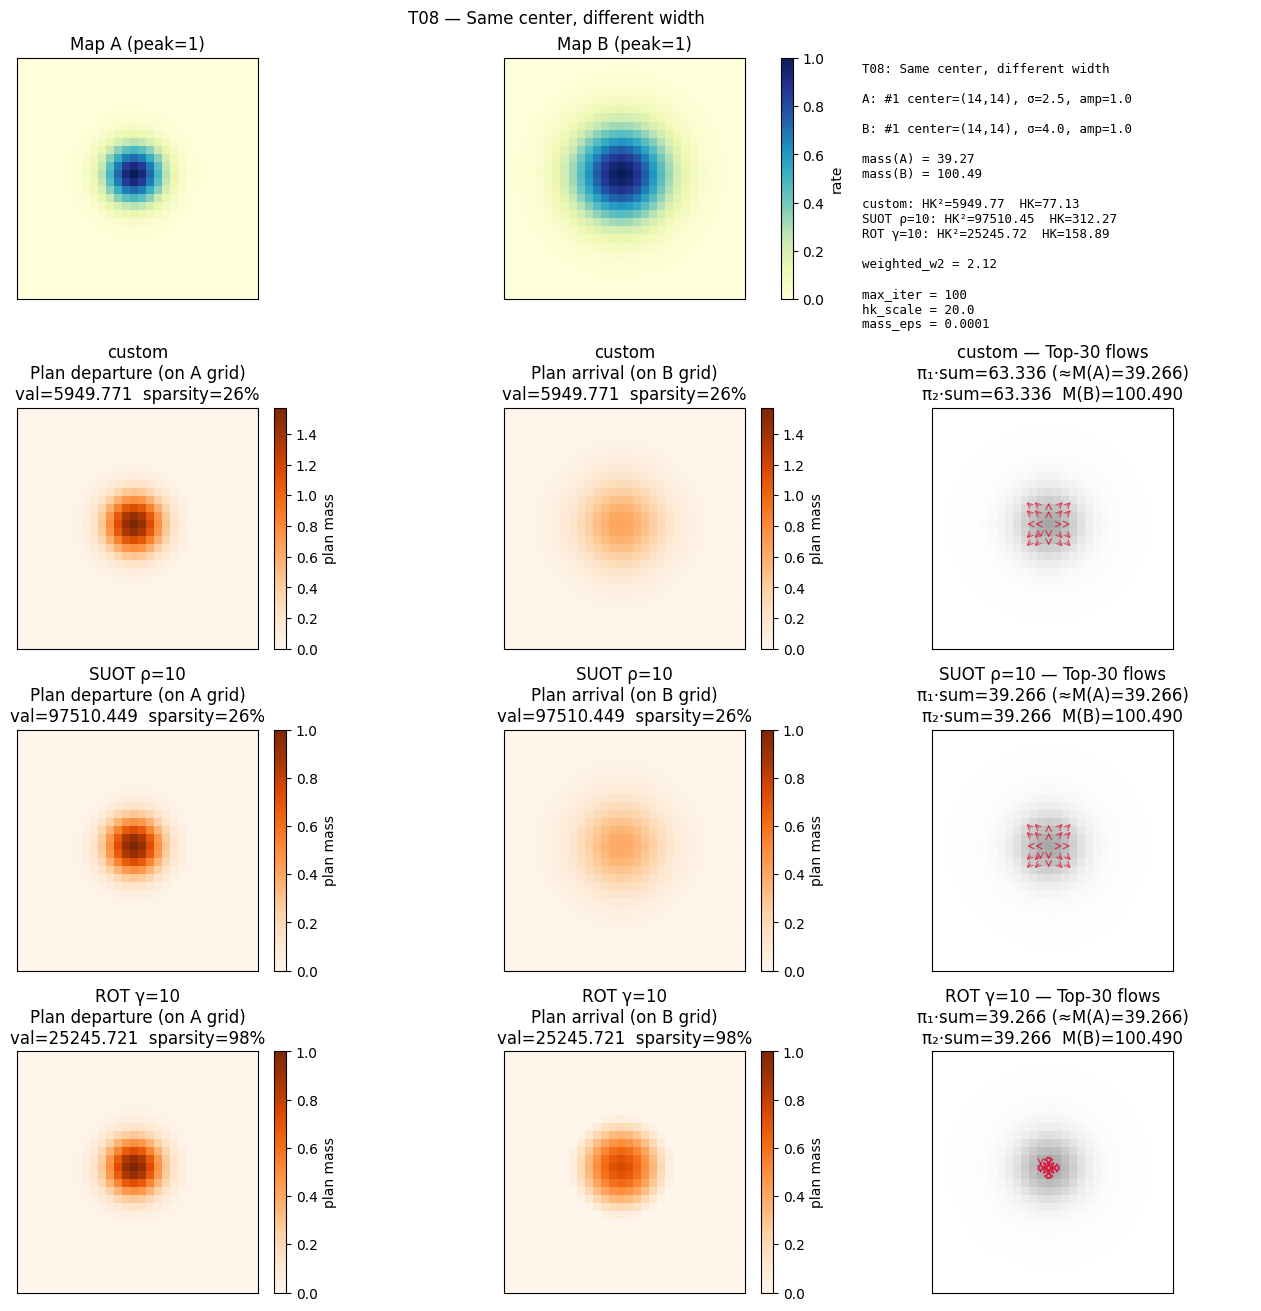

In [11]:
results.append(run_hk_test(
    "T08",
    "Same center, different width",
    [B(14, 14, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(14, 14, {'sigma': 4.0, 'amplitude': 1.0})],
))

### T09: Shifted copy (+5 px diagonal)

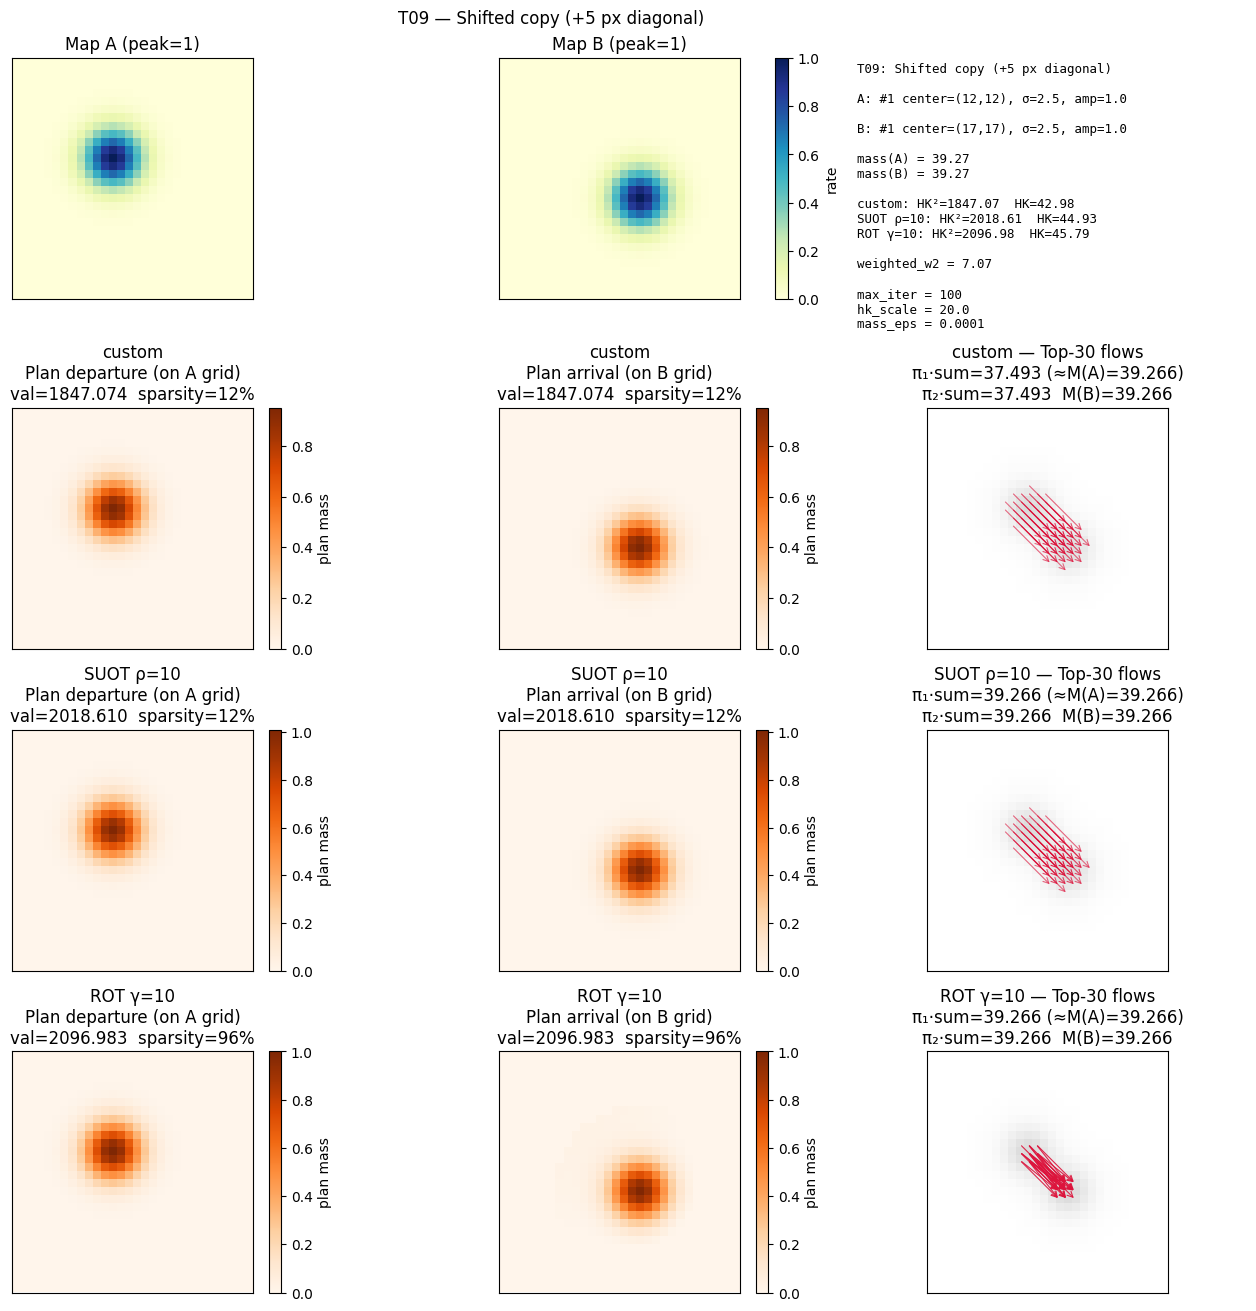

In [12]:
results.append(run_hk_test(
    "T09",
    "Shifted copy (+5 px diagonal)",
    [B(12, 12, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(17, 17, {'sigma': 2.5, 'amplitude': 1.0})],
))

### T10: Double top vs identical double top

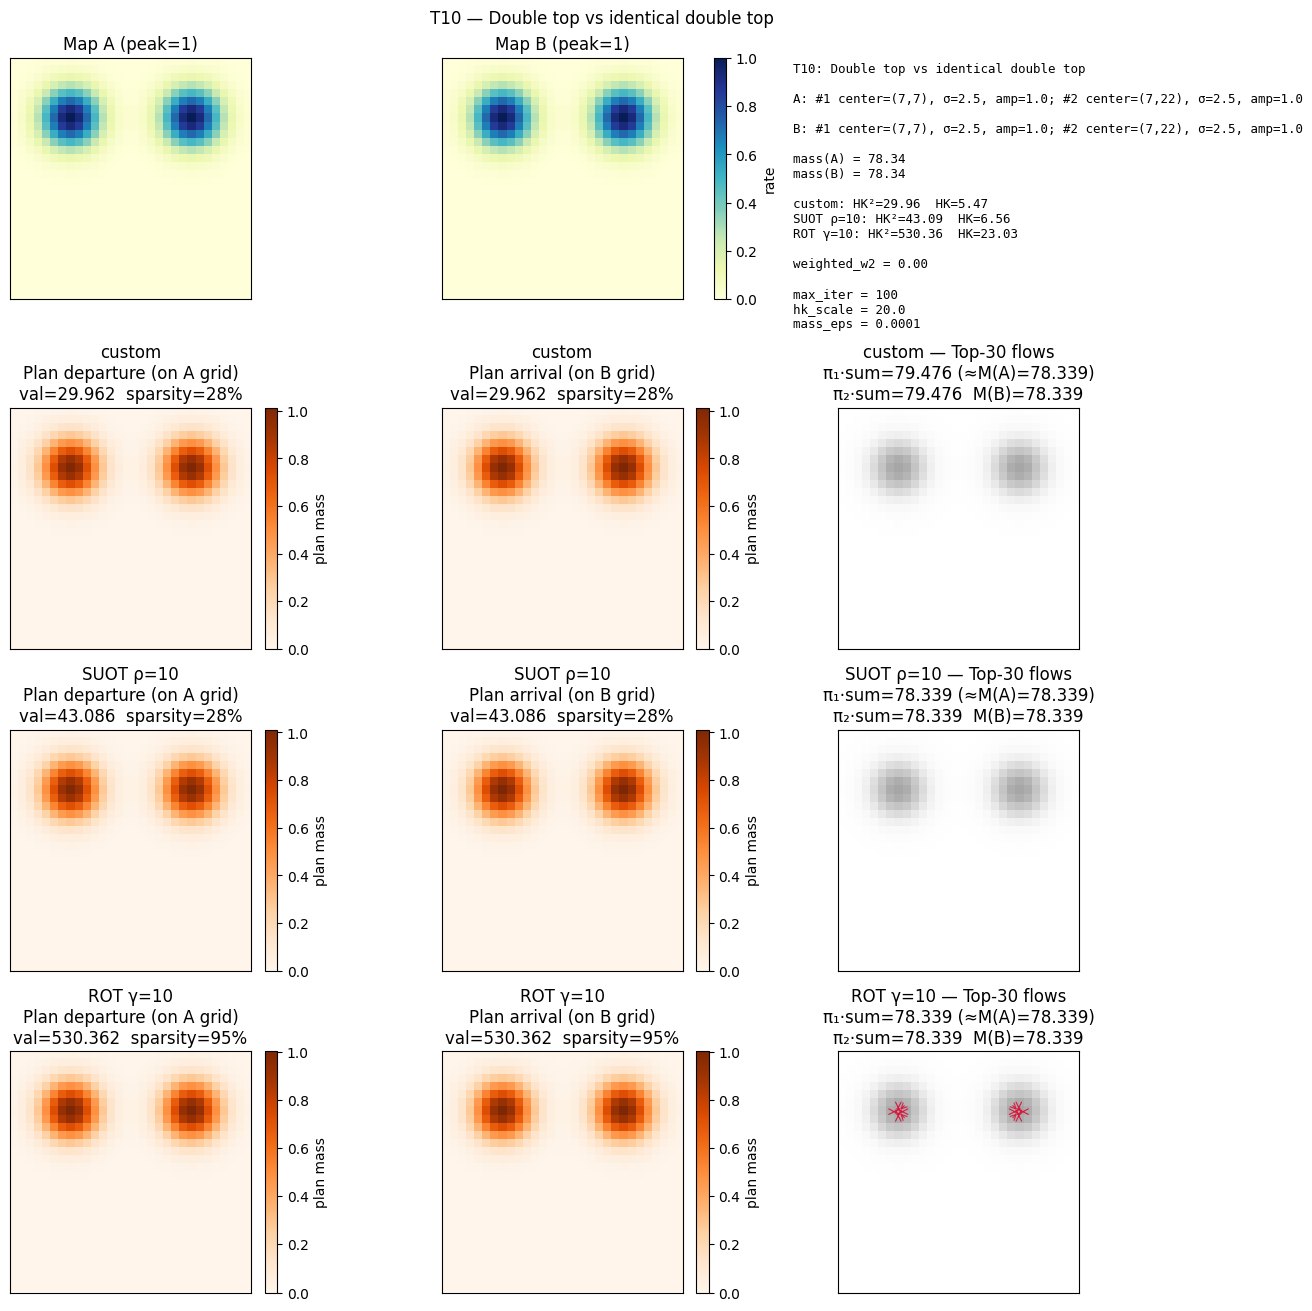

In [13]:
results.append(run_hk_test(
    "T10",
    "Double top vs identical double top",
    [B(7, 7, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 22, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(7, 7, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 22, {'sigma': 2.5, 'amplitude': 1.0})],
))

### T11: Three blobs top vs single bottom center

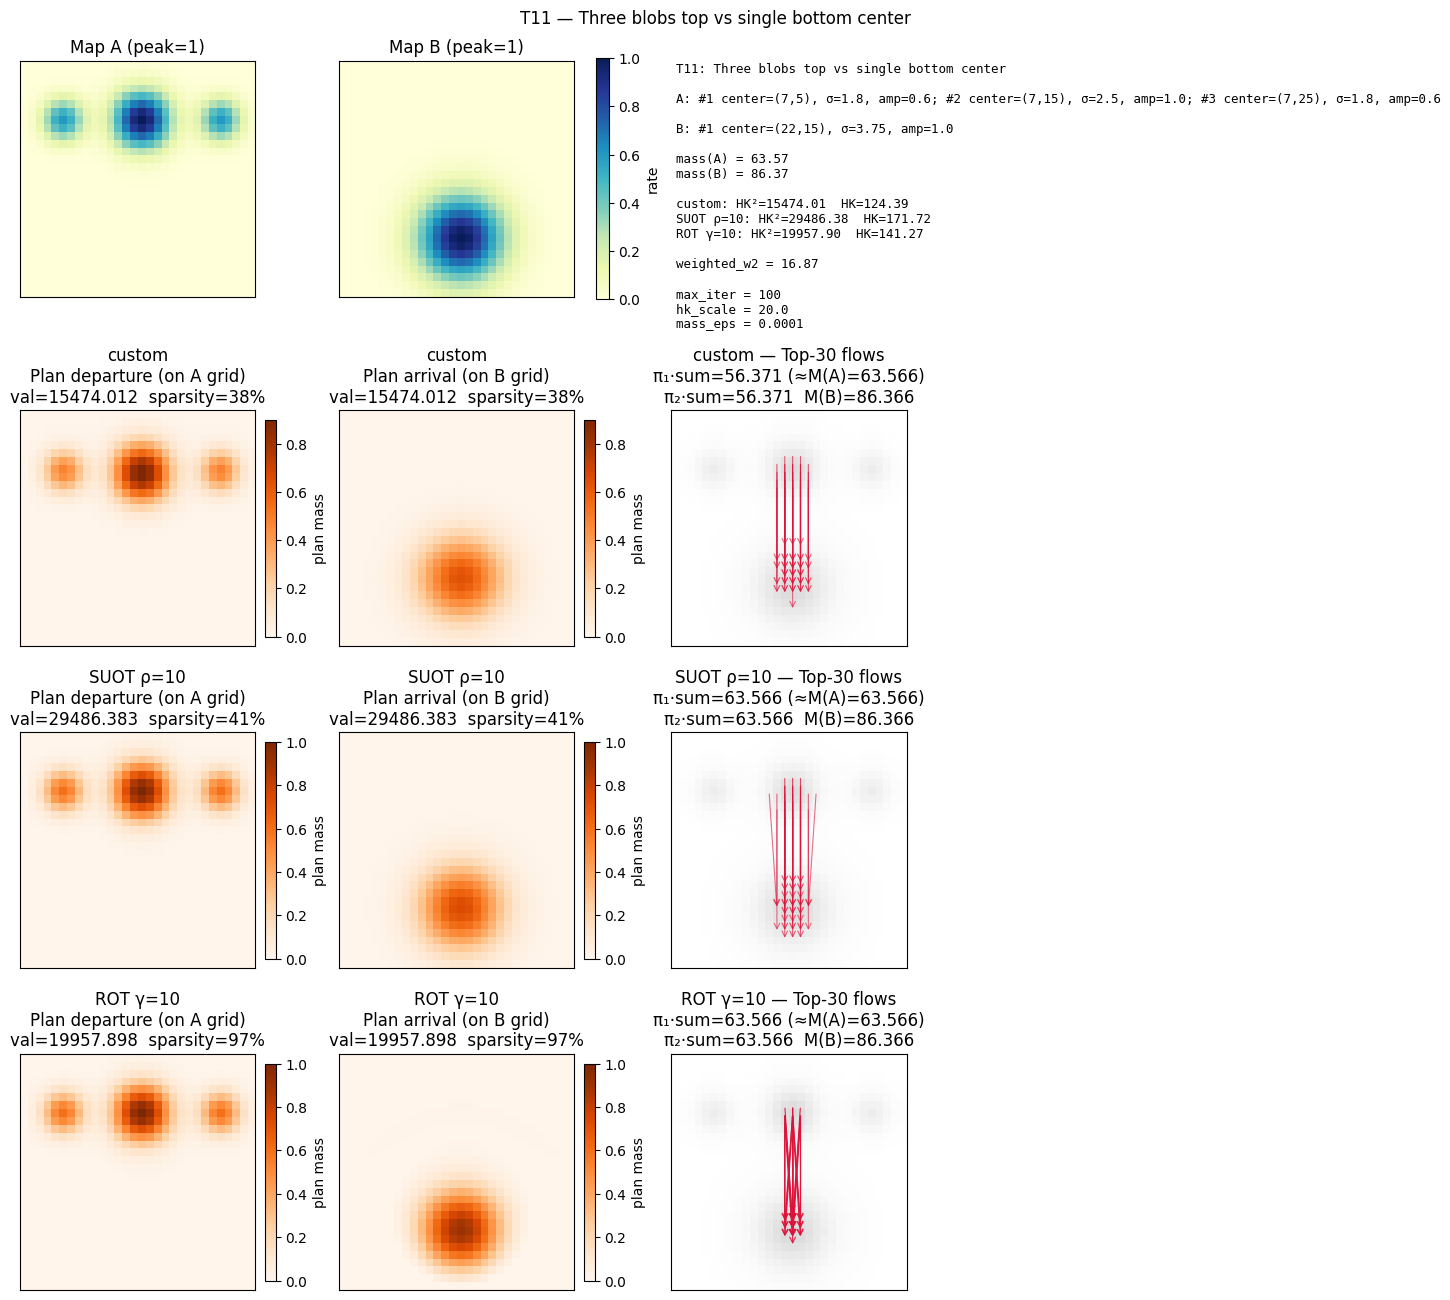

In [14]:
results.append(run_hk_test(
    "T11",
    "Three blobs top vs single bottom center",
    [B(7, 5, {'sigma': 1.8, 'amplitude': 0.6}), B(7, 15, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 25, {'sigma': 1.8, 'amplitude': 0.6})],
    [B(22, 15, {'sigma': 3.75, 'amplitude': 1.0})],
))

### T12: Three blobs vs three blobs (shifted down)

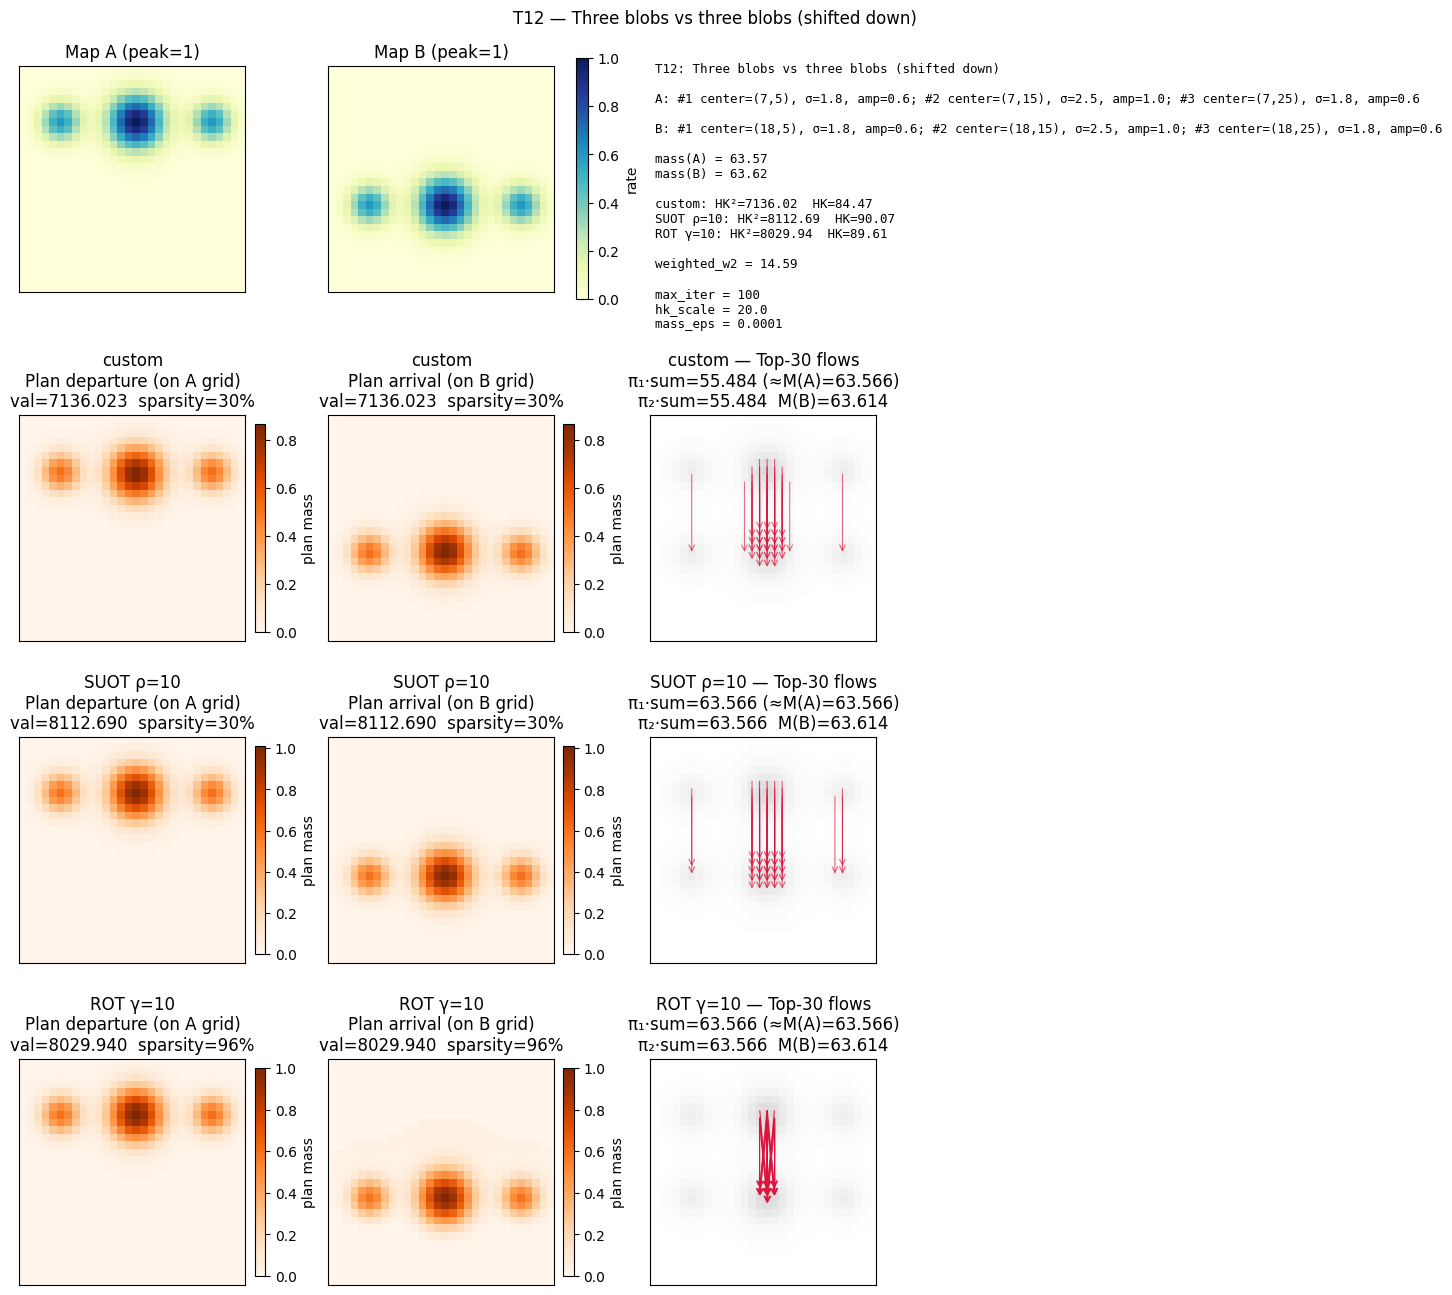

In [15]:
results.append(run_hk_test(
    "T12",
    "Three blobs vs three blobs (shifted down)",
    [B(7, 5, {'sigma': 1.8, 'amplitude': 0.6}), B(7, 15, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 25, {'sigma': 1.8, 'amplitude': 0.6})],
    [B(18, 5, {'sigma': 1.8, 'amplitude': 0.6}), B(18, 15, {'sigma': 2.5, 'amplitude': 1.0}), B(18, 25, {'sigma': 1.8, 'amplitude': 0.6})],
))

### T13: Three blobs top vs single top center

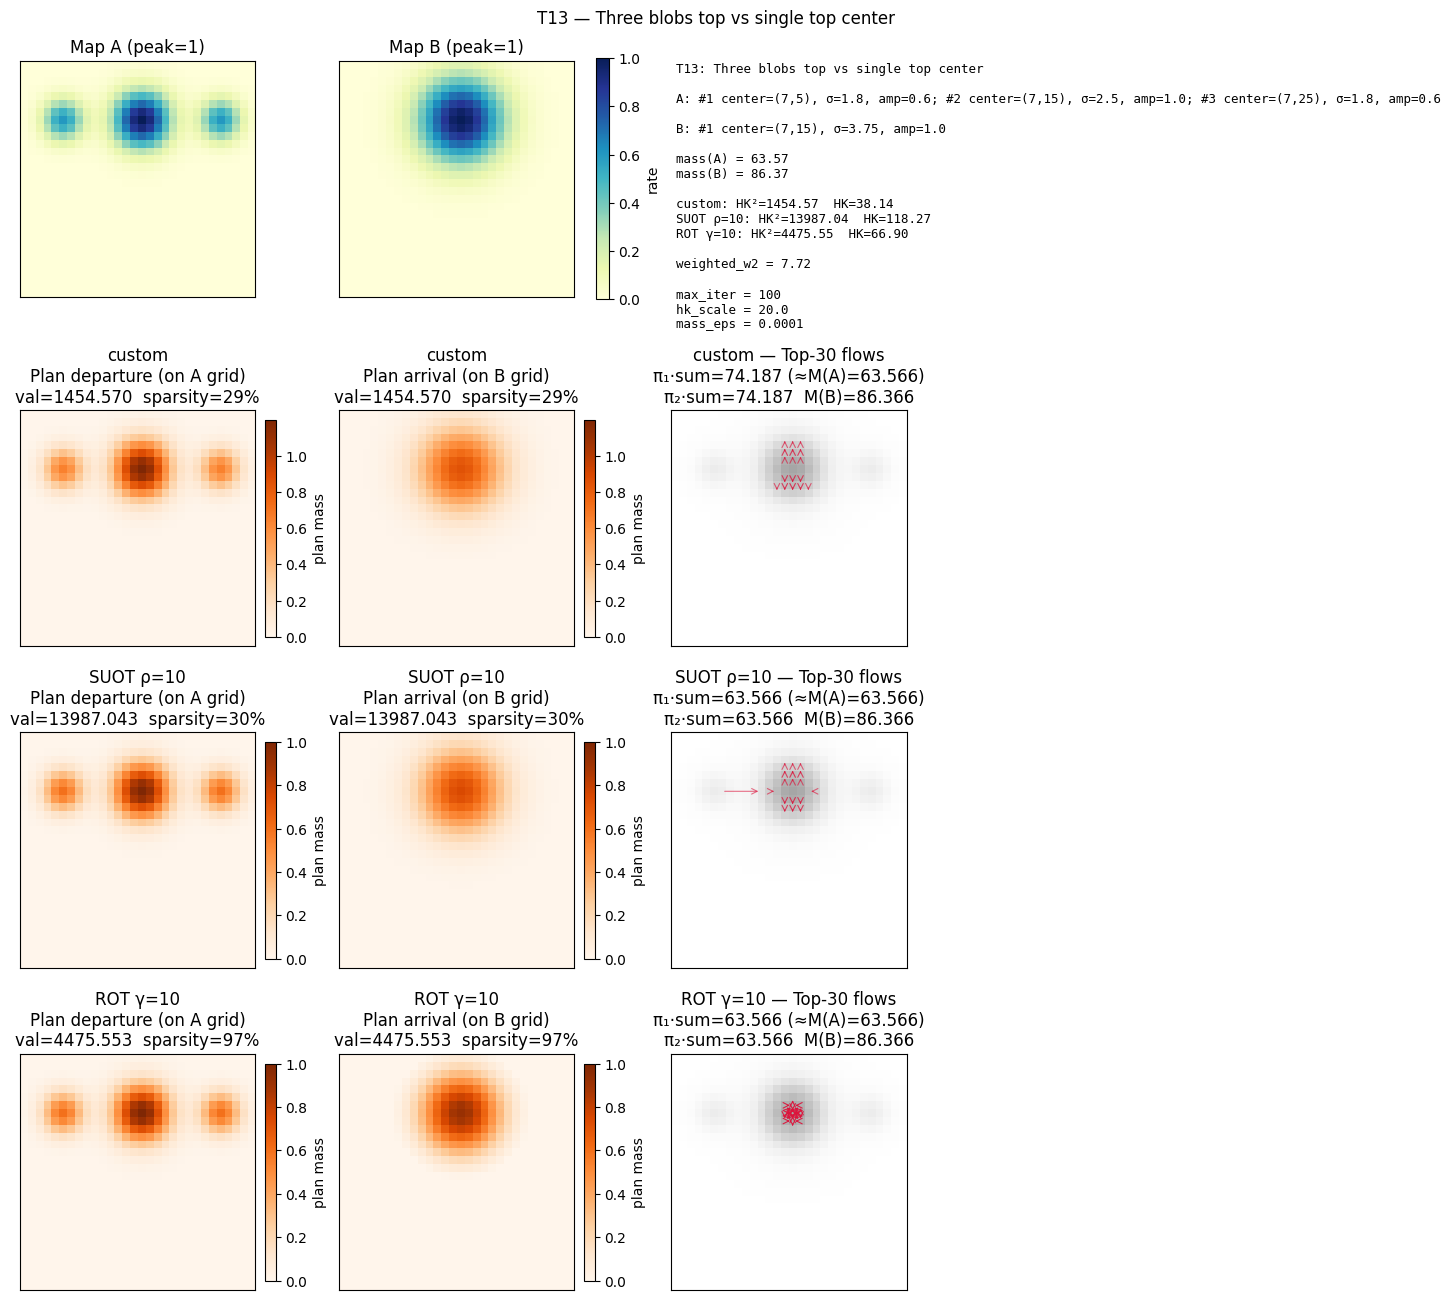

In [16]:
results.append(run_hk_test(
    "T13",
    "Three blobs top vs single top center",
    [B(7, 5, {'sigma': 1.8, 'amplitude': 0.6}), B(7, 15, {'sigma': 2.5, 'amplitude': 1.0}), B(7, 25, {'sigma': 1.8, 'amplitude': 0.6})],
    [B(7, 15, {'sigma': 3.75, 'amplitude': 1.0})],
))

### T14: Large center vs tiny corner blob

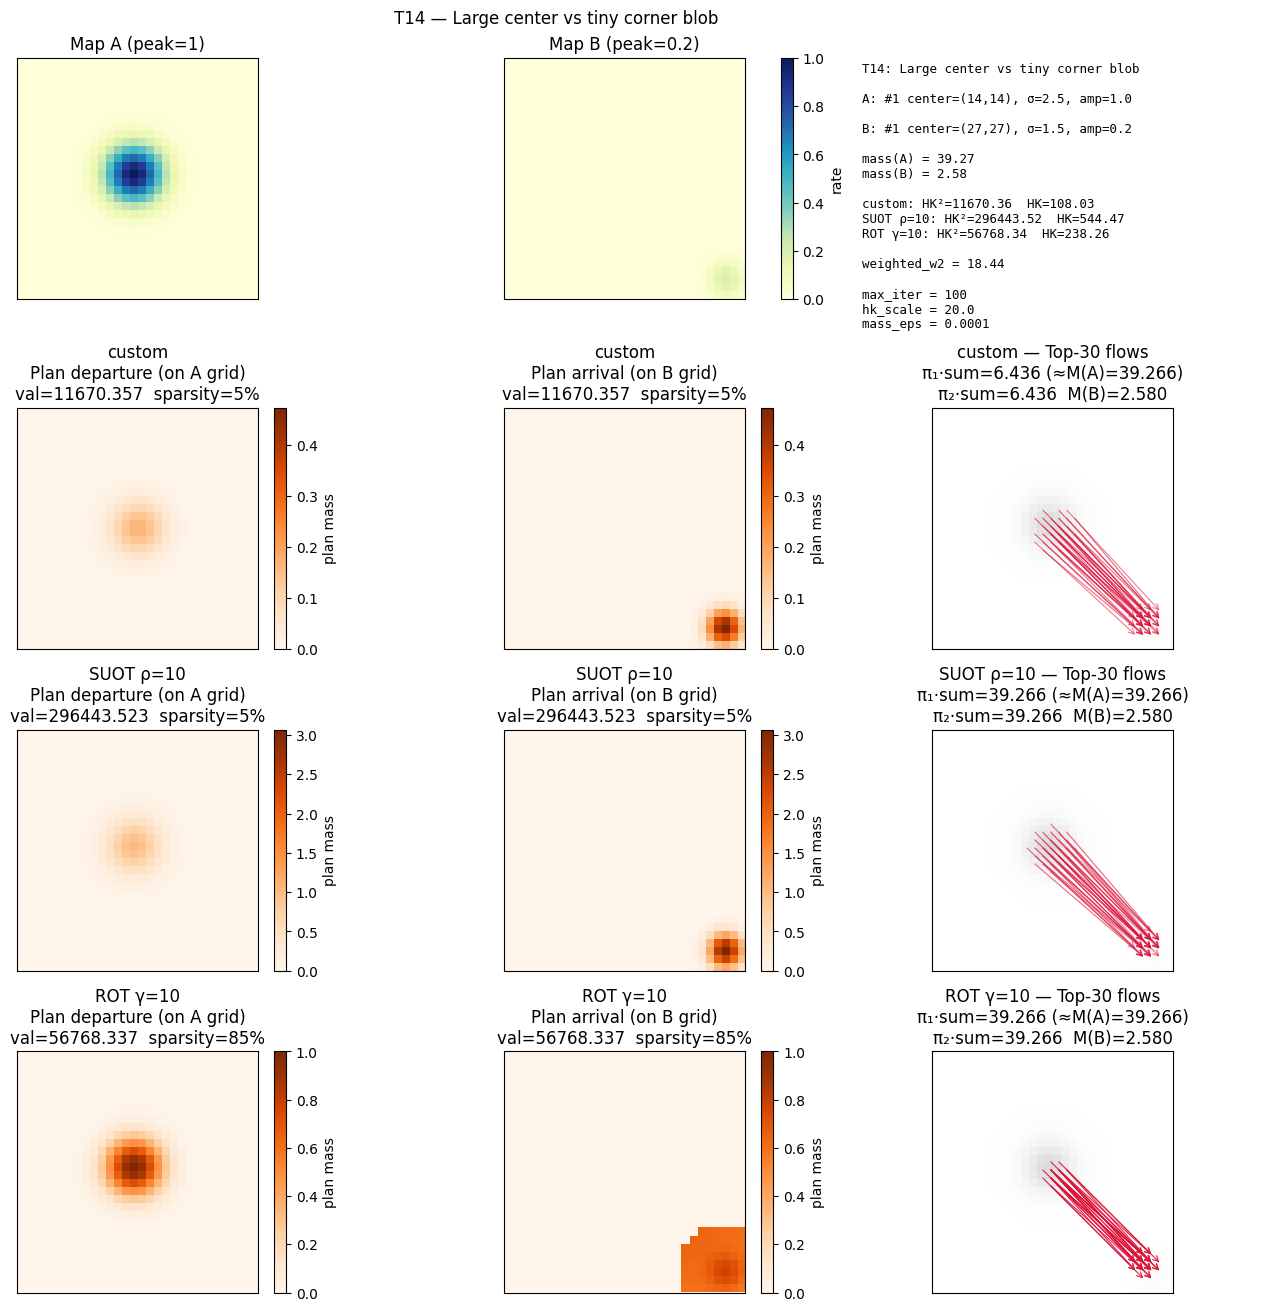

In [17]:
results.append(run_hk_test(
    "T14",
    "Large center vs tiny corner blob",
    [B(14, 14, {'sigma': 2.5, 'amplitude': 1.0})],
    [B(27, 27, {'sigma': 1.5, 'amplitude': 0.2})],
))

## Results summary

In [18]:
results_df = pd.DataFrame(results).sort_values("hk").reset_index(drop=True)
display(results_df[["test_id", "title", "mass_a", "mass_b", "hk2", "hk", "weighted_w2", "config_a", "config_b"]])

print(
    f"\nLowest HK:  {results_df.iloc[0]['test_id']} — "
    f"{results_df.iloc[0]['title']} (HK={results_df.iloc[0]['hk']:.2f})"
)
print(
    f"Highest HK: {results_df.iloc[-1]['test_id']} — "
    f"{results_df.iloc[-1]['title']} (HK={results_df.iloc[-1]['hk']:.2f})"
)

,test_id,title,mass_a,mass_b,hk2,hk,weighted_w2,config_a,config_b
0,T06,"Identical large blob (self, bias baseline)",39.269908,39.269908,15.142001,3.891272,0.000000,"#1 center=(14,14), σ=2.5, amp=1.0","#1 center=(14,14), σ=2.5, amp=1.0"
1,T10,Double top vs identical double top,78.341435,78.341435,29.961807,5.473738,0.000000,"#1 center=(7,7), σ=2.5, amp=1.0; #2 center=(7,...","#1 center=(7,7), σ=2.5, amp=1.0; #2 center=(7,..."
2,T07,"Same position, different amplitude",39.269908,19.634954,1358.722553,36.860854,0.000000,"#1 center=(14,14), σ=2.5, amp=1.0","#1 center=(14,14), σ=2.5, amp=0.5"
3,T13,Three blobs top vs single top center,63.567814,86.369352,1454.569551,38.138819,7.723699,"#1 center=(7,5), σ=1.8, amp=0.6; #2 center=(7,...","#1 center=(7,15), σ=3.75, amp=1.0"
4,T05,Double top vs single top center,78.341435,86.369352,1835.697901,42.845045,12.699776,"#1 center=(7,7), σ=2.5, amp=1.0; #2 center=(7,...","#1 center=(7,15), σ=3.75, amp=1.0"
5,T09,Shifted copy (+5 px diagonal),39.269889,39.269889,1847.073642,42.977595,7.071068,"#1 center=(12,12), σ=2.5, amp=1.0","#1 center=(17,17), σ=2.5, amp=1.0"
6,T02,Very close (~2.8 px),39.269908,12.214512,3272.495446,57.205729,2.996665,"#1 center=(14,14), σ=2.5, amp=1.0","#1 center=(16,16), σ=1.8, amp=0.6"
7,T08,"Same center, different width",39.269908,100.492676,5949.771010,77.134759,2.121320,"#1 center=(14,14), σ=2.5, amp=1.0","#1 center=(14,14), σ=4.0, amp=1.0"
8,T12,Three blobs vs three blobs (shifted down),63.567814,63.617668,7136.023429,84.474987,14.587452,"#1 center=(7,5), σ=1.8, amp=0.6; #2 center=(7,...","#1 center=(18,5), σ=1.8, amp=0.6; #2 center=(1..."
9,T01,Far apart (large top-right vs small bottom-left),39.170718,12.214213,11471.594136,107.105528,21.236290,"#1 center=(7,22), σ=2.5, amp=1.0","#1 center=(22,7), σ=1.8, amp=0.6"



Lowest HK:  T06 — Identical large blob (self, bias baseline) (HK=3.89)
Highest HK: T04 — Double top vs single bottom left (HK=140.02)


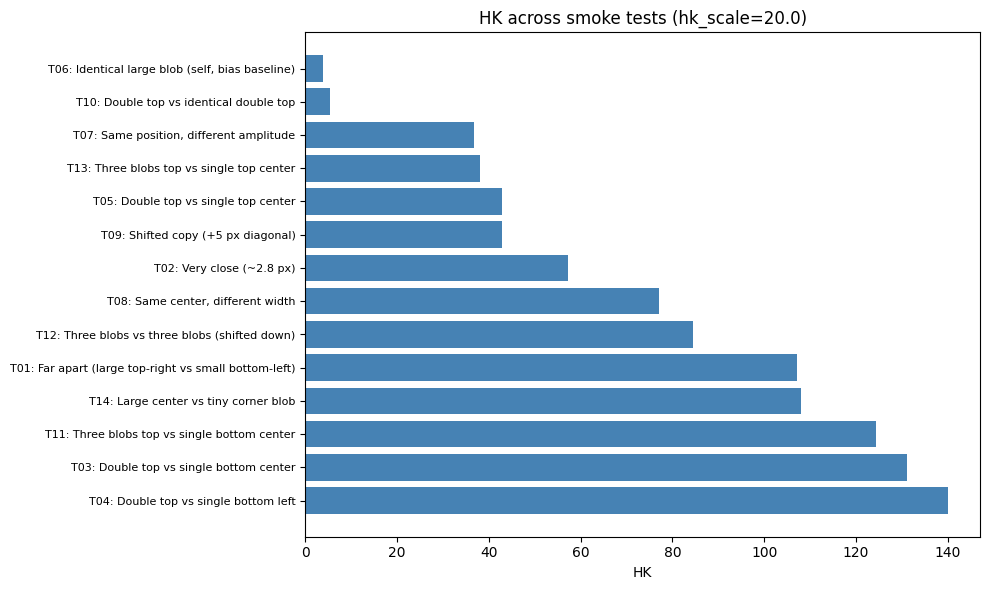

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = results_df["test_id"] + ": " + results_df["title"]
ax.barh(range(len(results_df)), results_df["hk"], color="steelblue")
ax.set_yticks(range(len(results_df)), labels=labels, fontsize=8)
ax.set_xlabel("HK")
ax.set_title(f"HK across smoke tests (hk_scale={HK_SCALE})")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## custom HK vs weighted_w2

Rank comparison and raw difference (`HK − weighted_w2`) across T01–T14.
Metrics use different scales (cone HK vs pixel-space W₂ on fitted Gaussians); rank agreement is the meaningful ordering check.

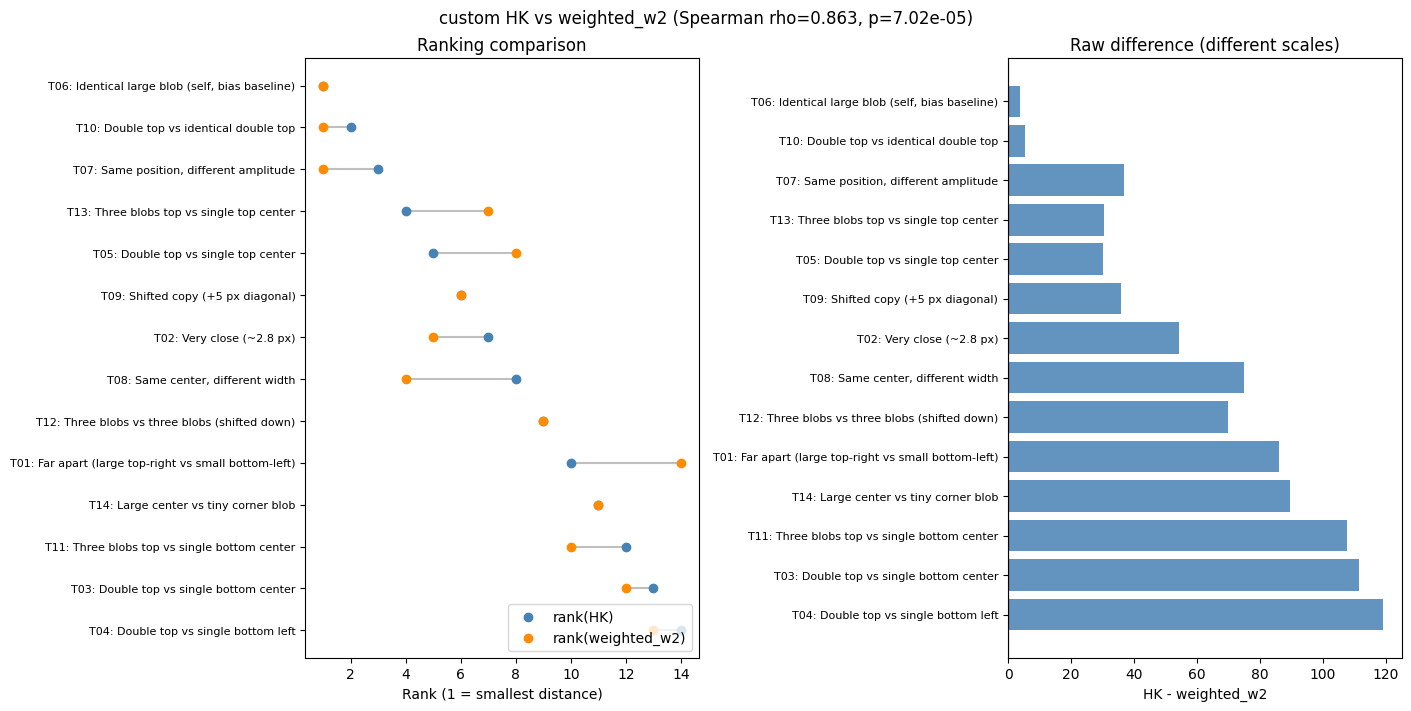

In [20]:
from scipy.stats import spearmanr

cmp_df = results_df.copy()
cmp_df["rank_hk"] = cmp_df["hk"].rank(method="min")
cmp_df["rank_w2"] = cmp_df["weighted_w2"].rank(method="min")
cmp_df["delta_hk_minus_w2"] = cmp_df["hk"] - cmp_df["weighted_w2"]

rho, pval = spearmanr(cmp_df["hk"], cmp_df["weighted_w2"])
labels = cmp_df["test_id"] + ": " + cmp_df["title"]
y = np.arange(len(cmp_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
fig.suptitle(
    f"custom HK vs weighted_w2 (Spearman rho={rho:.3f}, p={pval:.3g})",
    fontsize=12,
)

ax_rank = axes[0]
ax_rank.hlines(y, cmp_df["rank_hk"], cmp_df["rank_w2"], color="gray", alpha=0.5, lw=1.5)
ax_rank.scatter(cmp_df["rank_hk"], y, color="steelblue", label="rank(HK)", zorder=3)
ax_rank.scatter(cmp_df["rank_w2"], y, color="darkorange", label="rank(weighted_w2)", zorder=3)
ax_rank.set_yticks(y, labels=labels, fontsize=8)
ax_rank.set_xlabel("Rank (1 = smallest distance)")
ax_rank.set_title("Ranking comparison")
ax_rank.invert_yaxis()
ax_rank.legend(loc="lower right")

ax_delta = axes[1]
colors = np.where(cmp_df["delta_hk_minus_w2"] >= 0, "steelblue", "darkorange")
ax_delta.barh(y, cmp_df["delta_hk_minus_w2"], color=colors, alpha=0.85)
ax_delta.axvline(0, color="black", lw=0.8)
ax_delta.set_yticks(y, labels=labels, fontsize=8)
ax_delta.set_xlabel("HK - weighted_w2")
ax_delta.set_title("Raw difference (different scales)")
ax_delta.invert_yaxis()

plt.show()

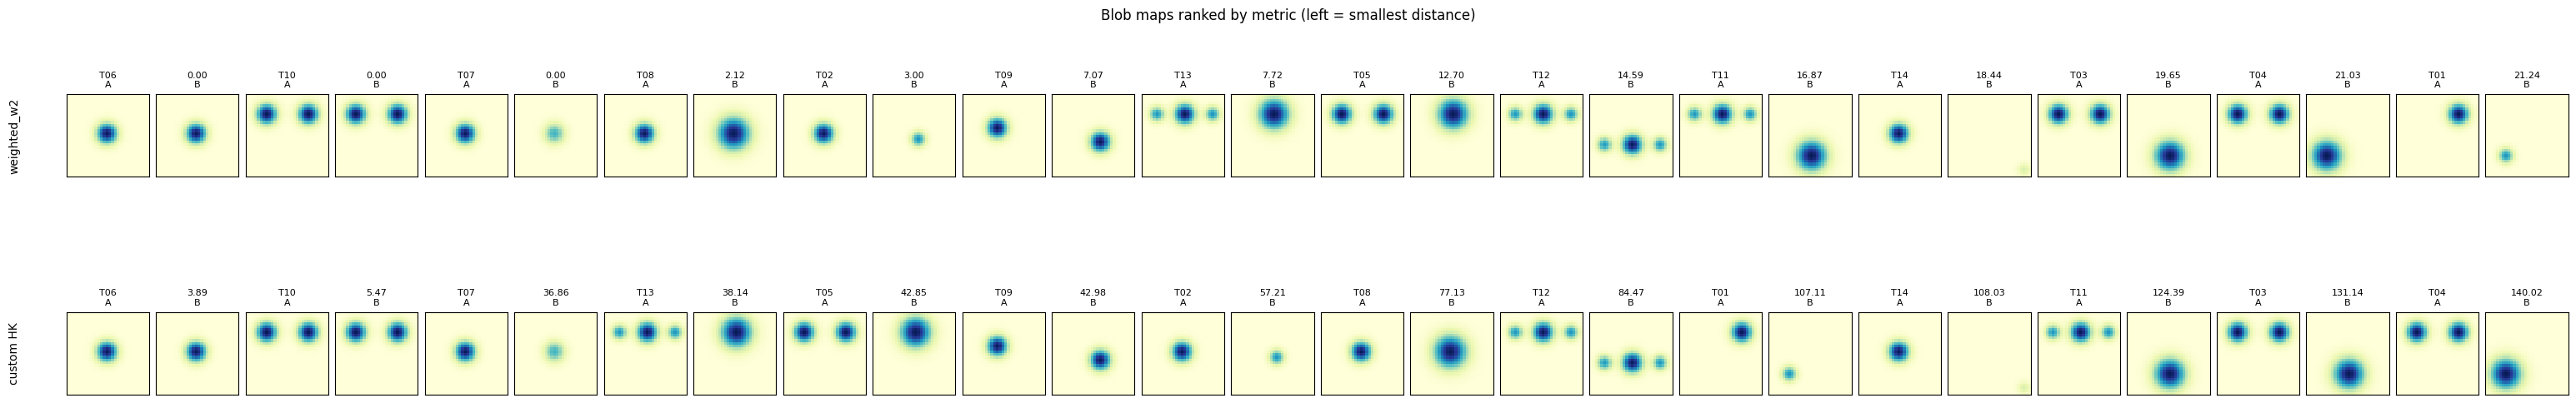

In [21]:
maps_by_id = {r["test_id"]: (r["map_a"], r["map_b"]) for r in results}
n_exp = len(results_df)
order_w2 = results_df.sort_values("weighted_w2").reset_index(drop=True)
order_hk = results_df.sort_values("hk").reset_index(drop=True)

fig, axes = plt.subplots(
    2,
    2 * n_exp,
    figsize=(2.2 * n_exp, 5.5),
    constrained_layout=True,
)
fig.suptitle("Blob maps ranked by metric (left = smallest distance)", fontsize=12)

row_specs = [
    ("weighted_w2", order_w2, "weighted_w2"),
    ("custom HK", order_hk, "hk"),
]

for row_idx, (row_label, ordered, metric_col) in enumerate(row_specs):
    for col_idx, row in enumerate(ordered.itertuples()):
        map_a, map_b = maps_by_id[row.test_id]
        vmax = max(float(map_a.max()), float(map_b.max()), 1e-9)

        ax_a = axes[row_idx, 2 * col_idx]
        ax_b = axes[row_idx, 2 * col_idx + 1]
        ax_a.imshow(map_a, cmap="YlGnBu", vmin=0, vmax=vmax)
        ax_b.imshow(map_b, cmap="YlGnBu", vmin=0, vmax=vmax)
        ax_a.set_title(f"{row.test_id}\nA", fontsize=8)
        ax_b.set_title(f"{getattr(row, metric_col):.2f}\nB", fontsize=8)

        for ax in (ax_a, ax_b):
            ax.set_xticks([])
            ax.set_yticks([])

    axes[row_idx, 0].set_ylabel(row_label, fontsize=10, rotation=90, labelpad=40)

plt.show()

## Hard-source / soft-target methods: SUOT and ROT

Both variants enforce **π₁ = a exactly** (all source mass transported) while relaxing
the target marginal:

| Method | Target penalty | Plan density | Parameter |
|--------|----------------|--------------|-----------|
| `"suot"` | ρ · KL(π₂ ‖ b) | Dense (Sinkhorn) | `rho` — larger → balanced |
| `"rot"` | (γ/2) ‖π₂ − b‖² | **Sparse** (≤ \|B\| entries) | `gamma` — larger → balanced |

**Behaviour when M(A) > M(B)**: excess source mass creates extra mass at B locations.  
**Behaviour when M(A) < M(B)**: some B mass is locally destroyed (not reached by A).

References:
- SUOT: Mignon et al., *SIAM J. Imaging Sci.* 2025, Theorem 3.4 (RSUOT Sinkhorn)
- ROT: Blondel, Seguy, Rolet, *AISTATS* 2018, arXiv:1710.06276 (semi-relaxed primal)

In [22]:
def run_method_comparison(
    test_id,
    title,
    blobs_a,
    blobs_b,
    *,
    hk_scale=HK_SCALE,
    suot_rho=SUOT_RHO,
    rot_gamma=ROT_GAMMA,
    max_iter=1000,
    mass_eps=MASS_EPS_COMPARISON,
):
    """Run the same scenario with HK_METHOD, SUOT, and ROT side by side."""
    result = run_hk_test(
        test_id,
        title,
        blobs_a,
        blobs_b,
        hk_scale=hk_scale,
        method=HK_METHOD,
        max_iter=max_iter,
        suot_rho=suot_rho,
        rot_gamma=rot_gamma,
        mass_eps=mass_eps,
    )
    return {
        HK_METHOD: result["hk2"],
        f"SUOT ρ={suot_rho}": result["suot_hk2"],
        f"ROT γ={rot_gamma}": result["rot_hk2"],
    }

### Mass imbalance: M(A) > M(B)

Large blob (A) vs small blob (B).  With hard-source methods, **all** A mass must be
transported.  The excess mass appears as local creation at B.

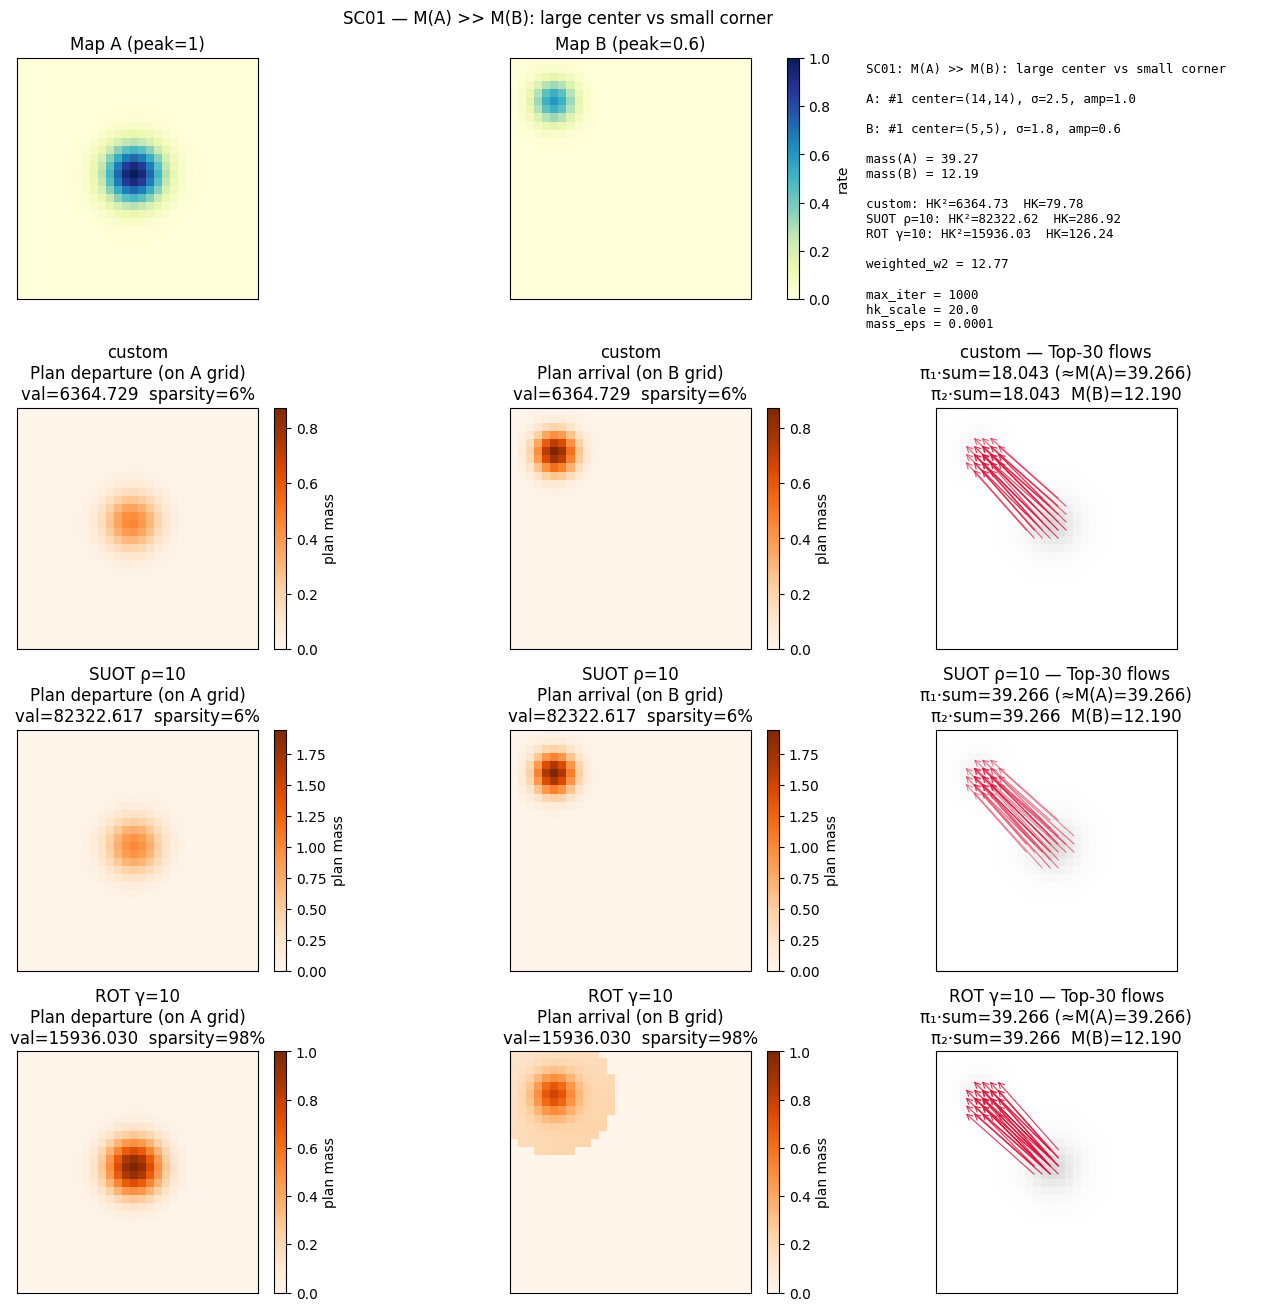

In [23]:
_ = run_method_comparison(
    "SC01",
    "M(A) >> M(B): large center vs small corner",
    [B(14, 14, LARGE)],
    [B(5,  5,  SMALL)],
)

### Mass imbalance: M(A) < M(B)

Small blob (A) vs large blob (B).  With hard-source methods, all A mass is transported
but it is not enough to fill B — B undergoes local deletion (some B mass unreached).

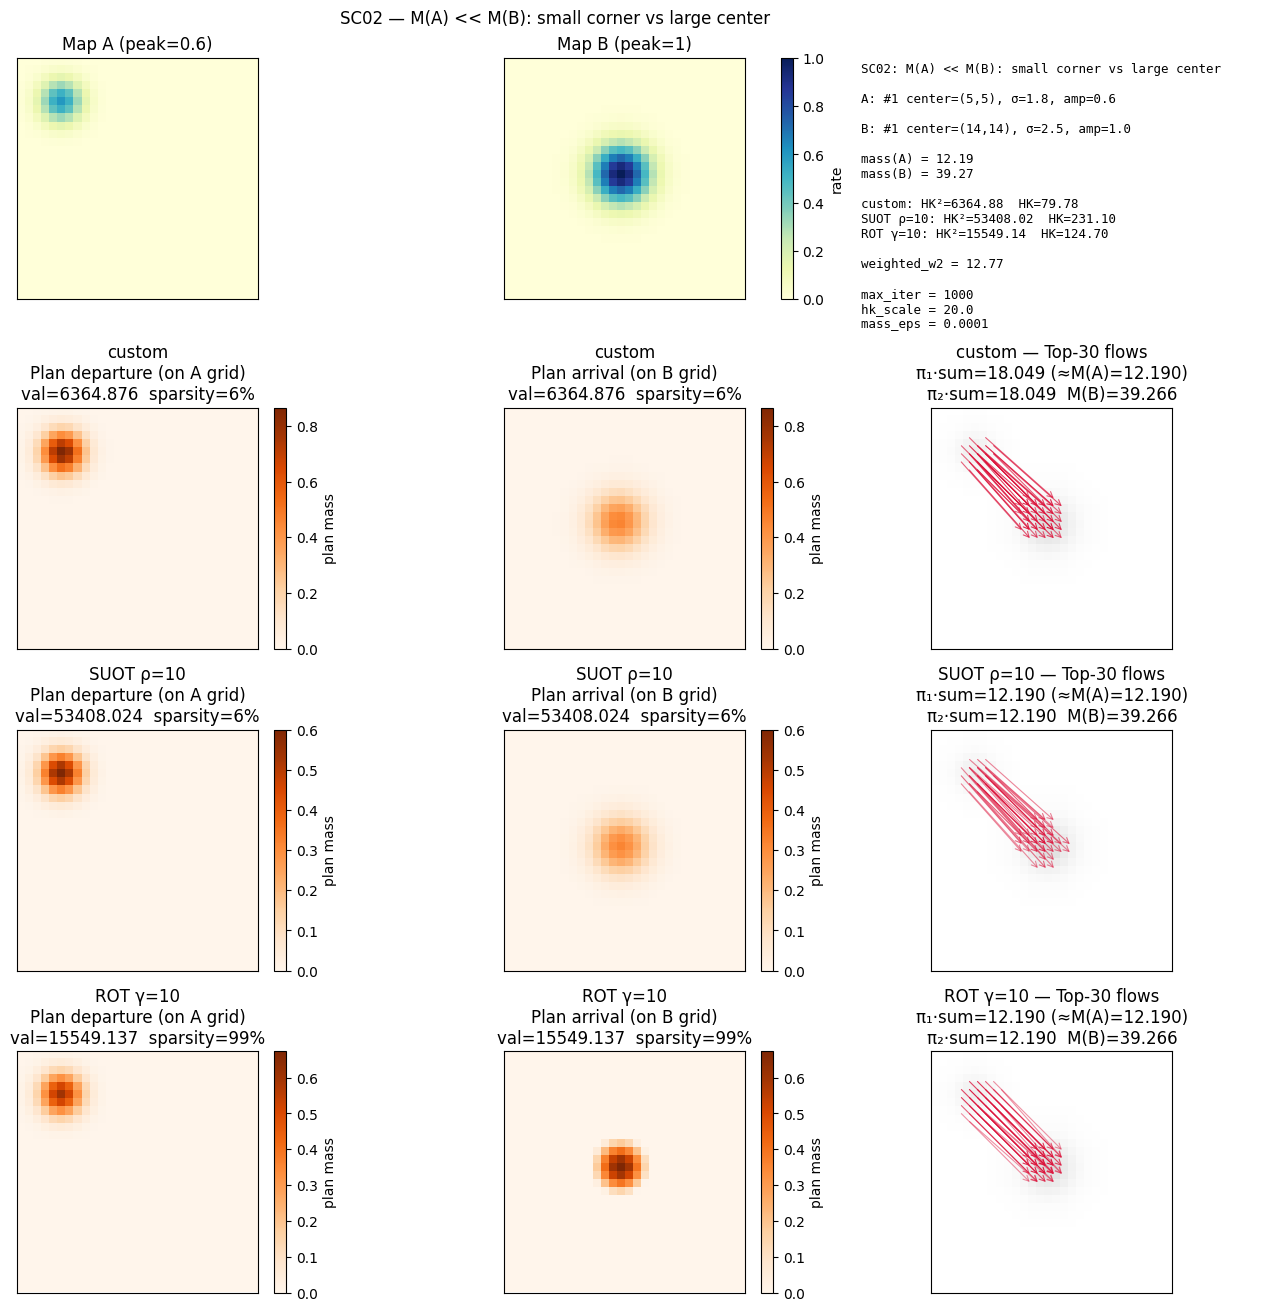

In [24]:
_ = run_method_comparison(
    "SC02",
    "M(A) << M(B): small corner vs large center",
    [B(5,  5,  SMALL)],
    [B(14, 14, LARGE)],
)

### Double A vs single B (mass imbalance + multi-source)

Two A blobs vs one B blob — classic scenario from the existing smoke tests,
now showing how hard-source methods distribute the full A mass.

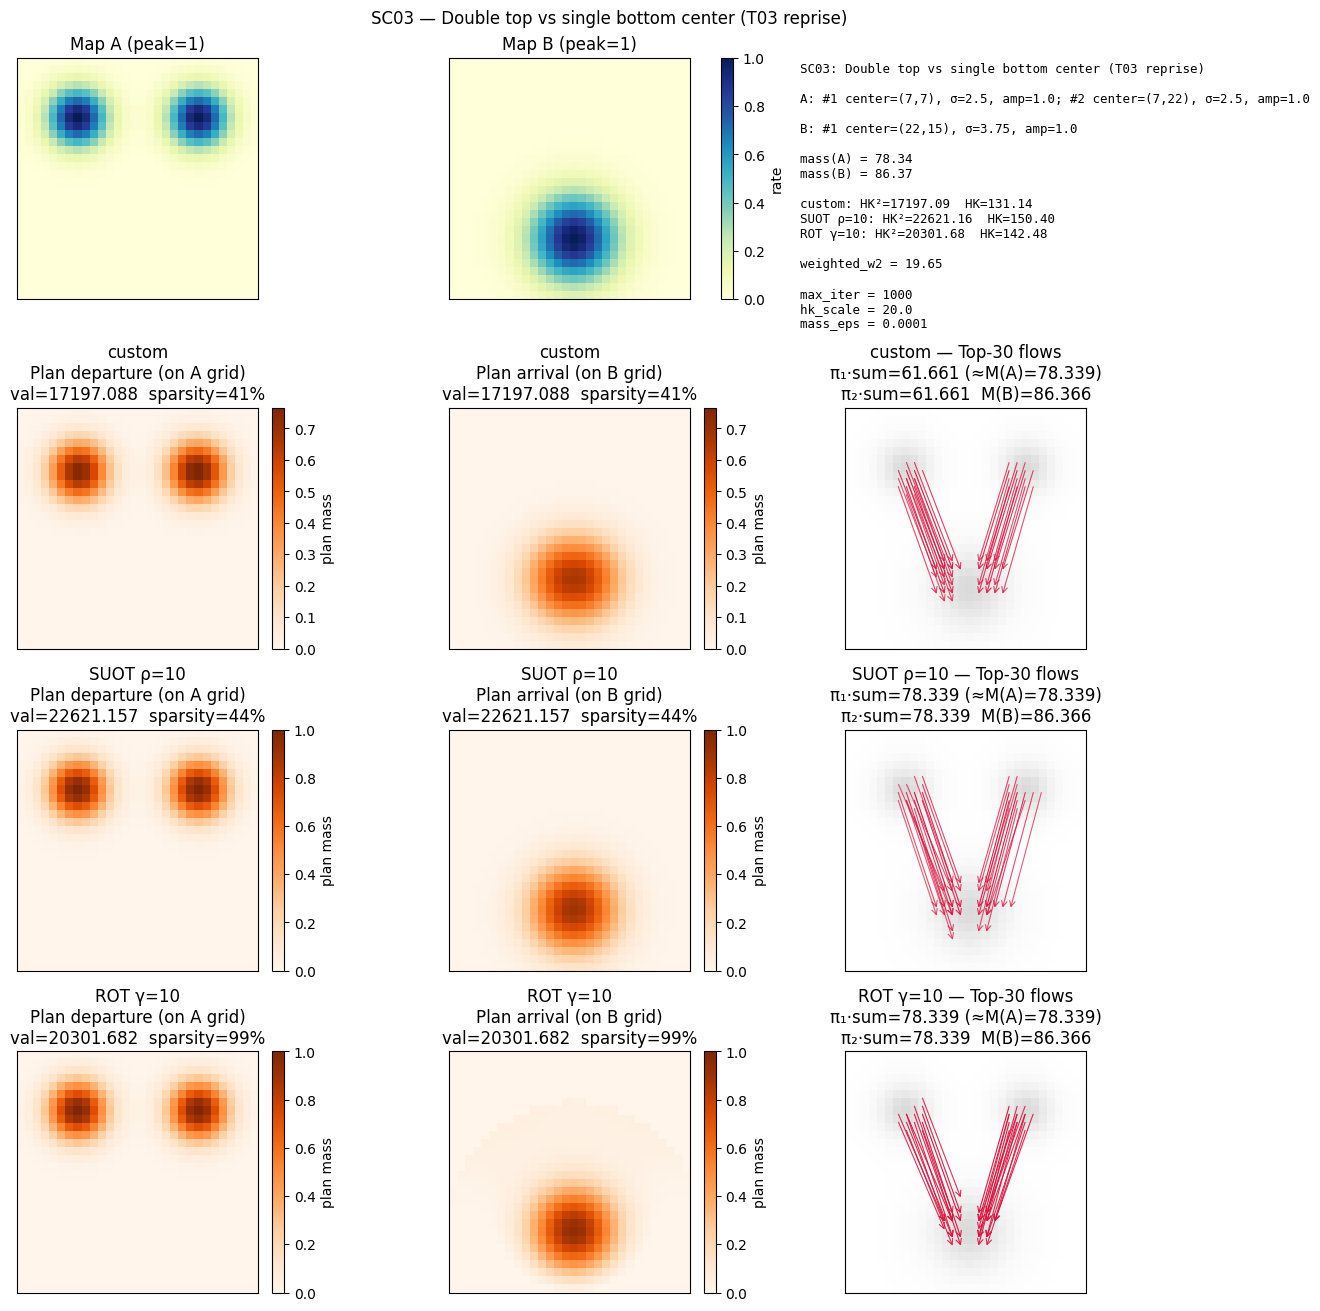

In [25]:
_ = run_method_comparison(
    "SC03",
    "Double top vs single bottom center (T03 reprise)",
    [B(7, 7, LARGE), B(7, 22, LARGE)],
    [B(22, 15, XLARGE)],
)

### Effect of ρ on SUOT (soft-target strength)

Sweep `rho` from very small (most relaxed: A concentrates on nearest B)
to very large (converges to balanced HK).  ROT `gamma` sweep shown too.

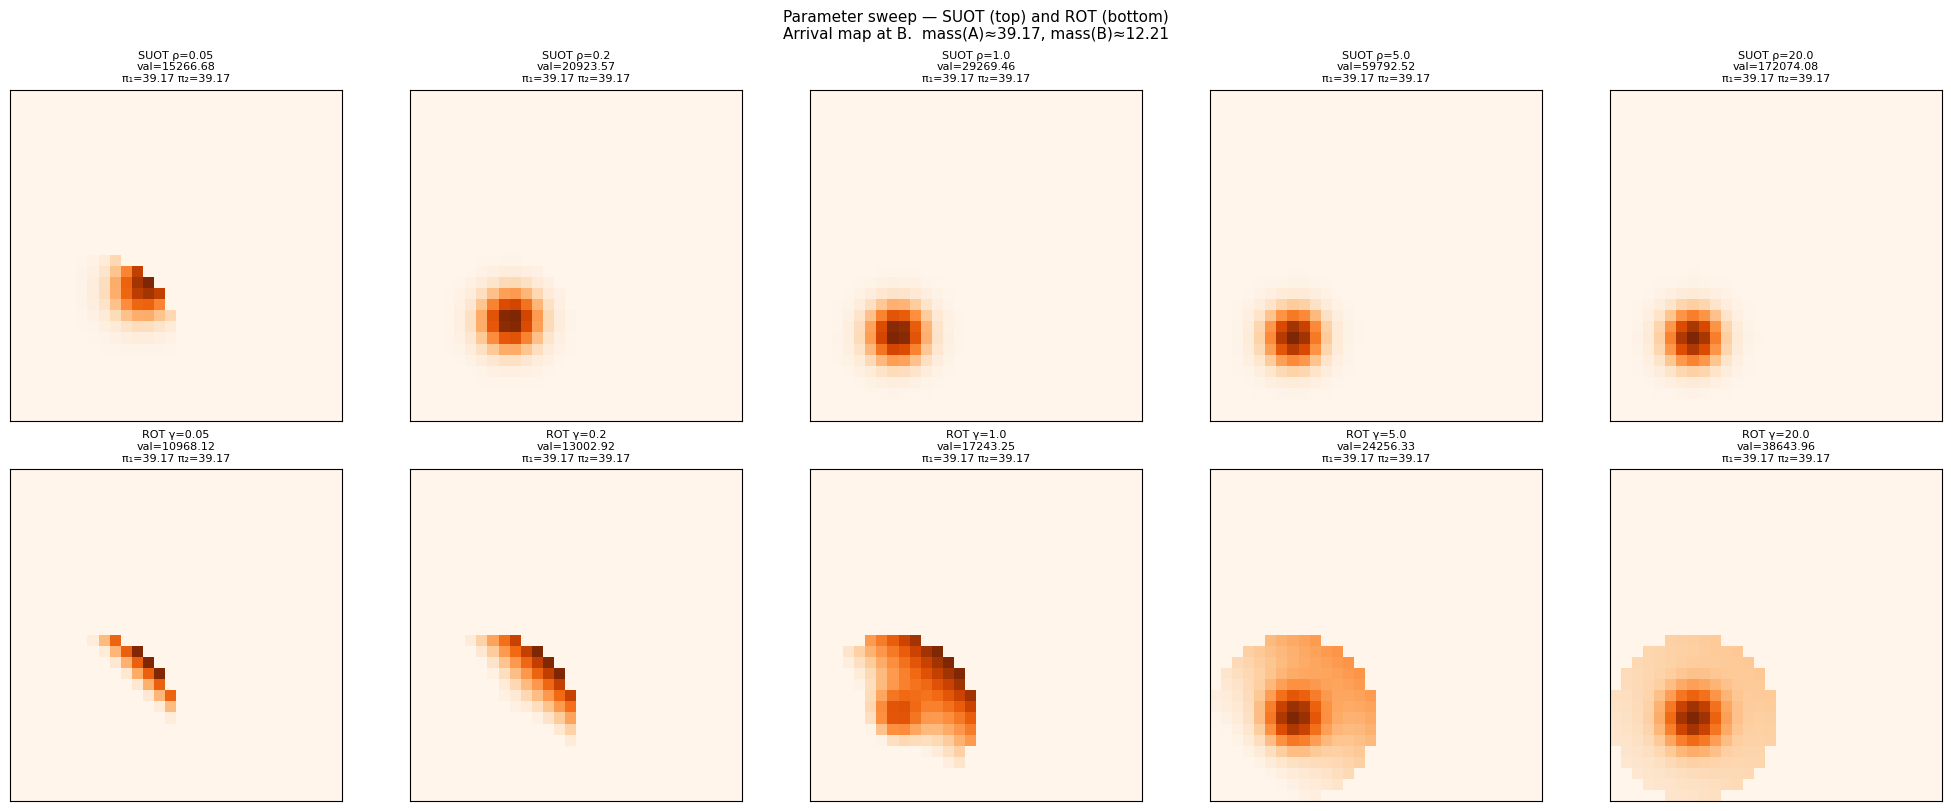

In [26]:
map_a_sw = build_map(GRID_SHAPE, [B(7, 22, LARGE)])
map_b_sw = build_map(GRID_SHAPE, [B(22, 7, SMALL)])

rho_vals   = [0.05, 0.2, 1.0, 5.0, 20.0]
gamma_vals = [0.05, 0.2, 1.0, 5.0, 20.0]

fig, axes = plt.subplots(2, len(rho_vals), figsize=(4 * len(rho_vals), 8),
                         constrained_layout=True)
fig.suptitle("Parameter sweep — SUOT (top) and ROT (bottom)\n"
             "Arrival map at B.  mass(A)≈{:.2f}, mass(B)≈{:.2f}".format(
                 map_a_sw.sum(), map_b_sw.sum()), fontsize=11)

for col, (rho, gamma) in enumerate(zip(rho_vals, gamma_vals)):
    for row, (method, kw, label) in enumerate([
        ("suot", {"rho": rho},    f"SUOT ρ={rho}"),
        ("rot",  {"gamma": gamma}, f"ROT γ={gamma}"),
    ]):
        val, plan, pos_a, pos_b, mu_a, mu_b = maps_hk_with_plan(
            map_a_sw, map_b_sw,
            method=method, hk_scale=HK_SCALE,
            sinkhorn_error=SINKHORN_ERROR,
            eps_target=EPS_TARGET, eps_init=EPS_INIT,
            max_iter=MAX_ITER,
            mass_eps=MASS_EPS_COMPARISON,
            **kw,
        )
        _, arrive = plan_on_grids(plan, pos_a, pos_b, GRID_SHAPE)
        dmax = max(arrive.max(), float(map_b_sw.max()), 1e-9)
        src_sum = plan.sum(axis=1).sum()
        tgt_sum = plan.sum(axis=0).sum()
        ax = axes[row, col]
        ax.imshow(arrive, cmap="Oranges", vmin=0, vmax=dmax)
        ax.set_title(f"{label}\nval={val:.2f}\nπ₁={src_sum:.2f} π₂={tgt_sum:.2f}",
                     fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

plt.show()